# Friends free recall scoring
**Contributors: James Antony. Code heavily borrowed from Antony et al. (2024, JoCN).**  

## Goals of this script
1. Import and analyze recall data in relation to narrative factors (Figs 1-2)

## Inputs
1. Event info (FriendsStoryboard.xlsx)
2. Ratings (causality/importance) (ratings/(subnum).xlsx)
3. Recall data for each subject (FriendsRecallScoring.xlsx)
 
## Outputs
1. Recall data for each event x subject
2. Network-related properties

## Parts
1. Import event info 
2. Import recall data from RA scoring guides and causality/importance
3. Plot basic relationships and create network plots
4. Examine transition-wise analyses

In [45]:
#if need to pip install w/in notebook
#!pip install pydot
#!pip install seaborn
#!pip install networkx
#!pip install openpyxl
#!pip install sentence_transformers

import os 
import sys 
import math
import time
import glob
import copy
import scipy
import random
import os.path
import scipy.io
import warnings 
import datetime
import matplotlib
import numpy as np
from os import path
import pandas as pd 
import networkx as nx
import seaborn as sns 
import numpy.ma as ma
from io import StringIO
from scipy import stats
from copy import deepcopy
from pprint import pprint 
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import ttest_ind
from scipy.stats import ttest_rel
from scipy.stats import ttest_1samp
import matplotlib.patches as patches
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from scipy.signal import gaussian, convolve
from numpy.polynomial.polynomial import polyfit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from scipy.stats import norm, zscore, pearsonr,spearmanr

#due to package version issues, I ran USE in Colab and imported the embeddings
#!pip install tensorflow_hub
#import tensorflow_hub as hub
#embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")
#model = SentenceTransformer('bert-base-nli-mean-tokens')

if not sys.warnoptions:
    warnings.simplefilter("ignore")
cfs=40 #defaults
plt.rcParams.update({'font.size': cfs})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
cm,cm2,fs0,fs1,fs2='gray','viridis',13,10,10 #colormap styles and fig sizes
figf="figs/"
%autosave 5
%matplotlib inline
sns.set(style = 'white', context='talk', font_scale=1, rc={"lines.linewidth": 2})

#preset variables
import fr_utils
from fr_utils import fr_dir, fr_bids_dir
results_path=fr_bids_dir+'derivatives/secondlevel/'
firstlevel_dir=fr_bids_dir+'derivatives/firstlevel/'
analysis_dir=fr_dir+'analysis/'
ses='ses-01'
dir_out = results_path + 'behav/'
xl_dir='/Users/jamesantony/Desktop/friends_fmri/data/behavioral/'
if not os.path.exists(dir_out): #create directory if it doesn't exist
    os.makedirs(dir_out)

Autosaving every 5 seconds


In [46]:
#functions
def findsecs(tstring): #find absolute # of seconds, based on HMS input
    date_time = datetime.datetime.strptime(tstring, "%H:%M:%S")
    a_timedelta = date_time - datetime.datetime(1900, 1, 1)
    seconds = a_timedelta.total_seconds()
    return seconds

def implot(v,dat,xl,yl,fs1,fs2,exv): #standard imshow plot
    f, ax = plt.subplots(1,1, figsize = (fs1,fs2))
    im=ax.imshow(dat.T,interpolation='none',cmap=cm,aspect='auto')
    ax.set_xlabel(xl,fontsize=cfs,color='black') 
    ax.set_ylabel(yl,fontsize=cfs,color='black') 
    ax.set_yticks(np.arange(len(v)))
    ax.set_yticklabels(v,fontsize=cfs,color='black')
    res=n_ev%5
    xt=np.linspace(0,n_ev-res,(n_ev-res)//5+1).astype(int)
    ax.set_xticks(xt)
    ax.set_xticklabels(xt,fontsize=cfs,color='black')
    if exv==0:
        xt=np.linspace(0,2500,6).astype(int)
        ax.set_xticks(xt)
        ax.set_xticklabels(xt,fontsize=cfs,color='black')
    elif exv==1:
        ax.set_xticklabels(xt,fontsize=cfs*2/3,color='black')
    elif exv==2:
        ax.set_xlabel(xl,fontsize=cfs*2/3,color='black') 
        ax.set_ylabel(yl,fontsize=cfs*2/3,color='black') 
        ax.set_yticklabels(v,fontsize=cfs*2/3,color='black')
        ax.set_xticklabels(xt,fontsize=cfs*2/3,color='black')
    elif exv==3:
        xt=np.linspace(0,2500,6).astype(int)
        ax.set_xticks(xt)
        ax.set_xticklabels(xt,fontsize=cfs,color='black')
        ax.set_ylabel(yl,fontsize=cfs*2/3,color='black') 
        ax.set_yticklabels(v,fontsize=cfs*2/3,color='black')
        yl=yl+"_TR"
    f.tight_layout()
    fn=figf + yl + ".pdf"
    plt.savefig(fn, transparent=True)
    
def histplot(lags,bins,xl,yl,fnx,tn):
    f, ax = plt.subplots(1,1,figsize = (fs1/2,fs2/2))
    ax.hist(lags,bins)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)        
    f.tight_layout()
    fn=figf+"time_"+fnx+".pdf"
    #plt.savefig(fn, transparent=True)
    ax.set_title(tn)
    
def plotscenev(y,yl,fn,inp,rdim): #plot mean causality/importance ratings
    f, ax = plt.subplots(1,1, figsize = (fs1,fs2/2))
    x=lin_ev+0
    if inp==1:
        plt.plot(x,y,color='k',linewidth=3)
        y1,err=[],[]
    elif inp==2: # y = 2-D, use errobar
        y1=np.nanmean(y,rdim)
        err=np.zeros((n_ev))
        for i in range(n_ev):
            y_adj=y[i,~np.isnan((y[i,:]))]
            err[i]=np.std(y_adj)/np.sqrt(y_adj.shape[0])
        plt.errorbar(x,y1,err,color='k',linewidth=3,elinewidth=2)
    ax.set_xlabel('Scene #')
    ax.set_ylabel(yl)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    f.tight_layout()
    plt.savefig(fn, transparent=True)
    return y1,err

def create_network(dat,thr,e_o): #create network graph
    # create state space and initial state probabilities
    slabs=[]
    for i in range(n_ev):
        slabs.append(str(i+1))

    pi = np.zeros((len(slabs)))
    pi[0]=1 #start in start state
    state_space = pd.Series(pi, index=slabs, name='states')
    q_df = pd.DataFrame(columns=slabs, index=slabs)
    for i in range(len(slabs)):
        q_df.loc[slabs[i]]=dat[i,:] # create transition matrix
    q=q_df.values
    edges_wts = _get_markov_edges(q_df)
    
    G=nx.MultiDiGraph() # create graph object
    G.add_nodes_from(slabs) # nodes correspond to states
    # edges represent transition probabilities - create below
    j=0
    for k, v in edges_wts.items():
        tmp_origin, tmp_destination = k[0], k[1]
        if v>thr: #0
            G.add_edge(tmp_origin,tmp_destination,weight=v,label=v,color='black')
            #note: changed since Memento
            #if tmp_origin > tmp_destination:
            if j==0:
                color_map_e=[1,0,0]
                j=1
            else:
                color_map_e=np.vstack([color_map_e,[1,0,0]])


    edge_weights0={(n1,n2):d['weight'] for n1,n2,d in G.edges(data=True)}
    edge_weights=list(edge_weights0.values())

    color_map=[]
    for node in range(n_ev):
        if e_o[node,1]==0:
            color_map.append('red')
        elif e_o[node,1]==1:
            color_map.append('green')
        elif e_o[node,1]==2:
            color_map.append('yellow')
        elif e_o[node,1]==3:
            color_map.append('cyan')
        elif e_o[node,1]==4:
            color_map.append('magenta')
    return G,edge_weights,color_map

# function that maps transition probability dataframe to markov edges and weights
def _get_markov_edges(Q):
    edges = {}
    for col in Q.columns:
        for idx in Q.index:
            edges[(idx,col)] = Q.loc[idx,col]
    return edges

def plot_trans_mat(dat,lab,exv):
    #f, ax = plt.subplots(1,1, figsize = (fs1/2,fs2/2))
    fs1,fs2=10,10
    xl,yl,cbl='Event #','Event #','Similarity'
    vm=1
    if exv==1: #override above based on exv
        xl,yl,cbl,vm='Effect event #','Cause event #','Mean causality rating',10
    elif exv==2:
        xl,yl,cbl,vm='Cause event #','Effect event #','Mean causality rating',10
    elif exv==3:
        xl,yl,cbl,vm='Next event #','Current event #','Recall transition likelihood',np.nanmax(dat)
    elif exv==4:
        xl,yl,cbl,vm='Effect event #','Cause event #','Top causal rating',1
    f, ax = plt.subplots(1,1, figsize = (fs1*2//3,fs2/2))
    im=ax.imshow(dat,interpolation='none',cmap=cm,aspect='auto',vmin=0,vmax=vm)
    ax.set_xlabel(xl,fontsize=fos,color='black')
    ax.set_ylabel(yl,fontsize=fos,color='black')
    ax.set_xticks(lin_ev[4::10])
    ax.set_yticks(lin_ev[4::10])
    ax.tick_params(axis="x", labelsize=fos*2/3,color='black')
    ax.tick_params(axis="y", labelsize=fos*2/3,color='black')
    cbar=f.colorbar(im)
    cbar.solids.set_edgecolor("face")
    cbar.ax.get_yaxis().labelpad = 10 #25 when rotation=270
    cbar.set_label(cbl,fontsize=fos*0.85,color='black', rotation=90)
    cbar.ax.tick_params(labelsize=fos*2/3,color='black') 
    f.tight_layout()
    fn=figf + lab + ".pdf"
    plt.savefig(fn, transparent=True)
    ax.set_title(lab,fontsize=fos*2/3)
    
    #reduced (no cbar)
    f, ax = plt.subplots(1,1, figsize = (fs1/2,fs2/2))
    im=ax.imshow(dat,interpolation='none',cmap=cm,aspect='auto',vmin=0,vmax=vm)
    ax.set_xlabel(xl,fontsize=fos,color='black')
    ax.set_ylabel(yl,fontsize=fos,color='black')
    ax.set_xticks(lin_ev[4::10])
    ax.set_yticks(lin_ev[4::10])
    ax.tick_params(axis="x",labelsize=fos*2/3,color='black')
    ax.tick_params(axis="y",labelsize=fos*2/3,color='black')
    f.tight_layout()
    fn=figf + lab + "_red.pdf"
    plt.savefig(fn, transparent=True)
    ax.set_title(lab,fontsize=fos*2/3)
    
def plot_embed2d(embeddings,figl): #plot 2D semantic embedding data
    emb_2d = np.zeros((n_ev,n_ev))
    for ev1 in range(n_ev):
        for ev2 in range(n_ev):
            if len(text[ev1])>0:
                if len(text[ev2])>0:
                    rval,pval=pearsonr(embeddings[ev1,:],embeddings[ev2,:])
                    emb_2d[ev1,ev2]=rval+0
                    if ev1==ev2: #zero diagonal
                        emb_2d[ev1,ev2]=0#math.nan
                else:
                    emb_2d[ev1,ev2]=0#math.nan
            else:
                emb_2d[ev1,ev2]=0
        
    plot_trans_mat(emb_2d,'trans_2D semantic similarity matrix',0)
    return emb_2d

def quicksp(x,y,xl,yl,fn): #quick scatterplots
    lw=4
    f, ax = plt.subplots(1,1,figsize = (9,6))
    ax.scatter(x,y,c='black')
    plt.xticks(fontsize=fos-5,color='black')
    plt.yticks(fontsize=fos-5,color='black')
    ax.set_xlabel(xl,fontsize=fos,color='black')
    ax.set_ylabel(yl,fontsize=fos,color='black')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(lw)
    ax.spines['left'].set_linewidth(lw)
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')
    a, b = np.polyfit(x,y, 1)
    rval,pval=pearsonr(x,y)
    rval_s,pval_s=spearmanr(x,y) #verify with spearman
    if isinstance(x, list):
        x = np.array(x)
    print('%s, pearson r = %.3f, p = %.3f, spearman r = %.3f, p = %.3f' %(xl,rval,pval,rval_s,pval_s))
    plt.plot(x, a*x+b,'k',linewidth=3)
    txt='$\it{r}$ = %.2f' %(rval) #text to put on plot
    if pval<0.05:
        txt='$\it{r}$ = %.2f*' %(rval)
        if pval<0.01:
          txt='$\it{r}$ = %.2f**' %(rval)
    plt.text(0.85, 0.15,txt,horizontalalignment='center',color='black',
     verticalalignment='center',transform = ax.transAxes,fontsize=fos) #0.2
    f.tight_layout()
    f.savefig(fn, transparent=True)
    
def network_plot(G,ew,node_szs,ed_mult,figl,fos): #plot network (Fig 1)
    f, ax = plt.subplots(1,1,figsize = (12,12))
    pos = nx.drawing.nx_pydot.graphviz_layout(G, prog='neato')

    nx.draw_networkx(G, pos,node_color=cmap_caus,edge_color='black',#node_color='white', #all same color nodes, use caus
                  font_size=fos,node_size=node_szs*no_mult,font_weight='bold')

    # create edge labels for jupyter plot but is not necessary
    edge_labels = {(n1,n2):d['label'] for n1,n2,d in G.edges(data=True)}
    edges=nx.draw_networkx_edges(G,pos,node_size=node_szs*no_mult,width=2,edge_color='k')
    M = G.number_of_edges()
    for i in range(M):
        edges[i].set_linewidth(ew[i]*ed_mult)
    f.tight_layout()
    fn="figs/"+figl+str(node_sz_meth)+".pdf"
    sps=['top','bottom','left','right']
    for i in range(len(sps)):
        ax.spines[sps[i]].set_visible(False)
    plt.savefig(fn, transparent=True)
    
#plot transition-wise strategy evidence
#clean this up w/ non-colab spacing
def plot_strat(dat,preds,fn,yl,exv,chl):
  lw=6
  f, ax = plt.subplots(1,1, figsize = (9,6))
  n_pred_use=len(preds)-2#n_pred+0
  if chl==1:
    n_pred_use=len(preds)#n_predp+0
  x=np.linspace(0,n_pred_use-1,n_pred_use)
  if exv==0:
    y=dat+0
    y1=np.nanmean(y,axis=0)
    s_ord=np.linspace(0,n_pred_use-1,n_pred_use).astype(int)
    preds_s_ord=[None]*n_pred_use
    for i in range(n_pred_use):
      preds_s_ord[i]=preds[s_ord[i]]
    err=np.zeros((n_pred_use))
    nnanv=len(np.where(y[:,0]>0)[0])
    for i in range(n_pred_use):
        err[i]=np.nanstd(y[:,i])/np.sqrt(nnanv)
    plt.bar(x,y1[s_ord],edgecolor='black',linewidth=lw-2,facecolor='white')
    plt.axhline(y=0,color='black',linestyle="--",linewidth=lw-3)
    plt.errorbar(x,y1[s_ord],err[s_ord],color='k',linewidth=0,elinewidth=lw-1)
  elif exv==1:
    currc=[1]
    for ii in range(len(currc)):
      y=dat+0 
      y1=np.nanmean(y,axis=0)
      s_ord=np.linspace(0,n_pred_use-1,n_pred_use).astype(int)
      preds_s_ord=[None]*n_pred_use
      for i in range(n_pred_use):
        preds_s_ord[i]=preds[s_ord[i]]
      err=np.zeros((n_pred_use))
      nnanv=len(np.where(y[:,0]>0)[0])
      for i in range(n_pred_use):
          err[i]=np.nanstd(y[:,i])/np.sqrt(nnanv)
      if ii==0:
        ccol=[0,0,1]
      elif ii==1:
        ccol=[1,0,0]
      plt.errorbar(x+(0.05*(int(ii)+1)),y1[s_ord],err[s_ord],color=ccol,linewidth=lw,elinewidth=lw)

  ax.set_xticks(np.arange(n_pred_use))
  ax.set_xticklabels(preds_s_ord,fontsize=21,rotation=30,color='black')
  ax.set_xlabel('Strategy',fontsize=24,color='black')
  ax.set_ylabel(yl,fontsize=24,color='black')
  ax.set_ylim([-0.05,0.8])
  if chl==1:
    ax.set_ylim([-0.05,0.4])
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  for axis in ['bottom','left']:
    ax.spines[axis].set_linewidth(lw-2)

  f.tight_layout()
  plt.savefig(fn, transparent=True)
    
def barswarm(d1,d2,d3,d4,d5,d6,d7,lab,yl,fn,exv): #d5,d6, #plot basic comparisons for >1 exp
    fs,fsz,msz=28,9,9
    lw=4
    if exv==1:
        xtl=[' Presented ',' Character ','   Place   ','  Semantic  ','Top semantic','   Causal   ',' Top causal ']
        dat1=pd.DataFrame({'Strategy':['Presented']*len(d1),lab:d1})
        dat2=pd.DataFrame({'Strategy':['Character']*len(d2),lab:d2})
        dat3=pd.DataFrame({'Strategy':['Place']*len(d3),lab:d3})
        dat4=pd.DataFrame({'Strategy':['Semantic']*len(d4),lab:d4})
        dat5=pd.DataFrame({'Strategy':['Top semantic']*len(d5),lab:d5})
        dat6=pd.DataFrame({'Strategy':['Causal']*len(d6),lab:d6})
        dat7=pd.DataFrame({'Strategy':['Top causal']*len(d7),lab:d7})
        ng=7
        dat = pd.concat([dat1, dat2],ignore_index=True)
        dat = pd.concat([dat, dat3],ignore_index=True)
        dat = pd.concat([dat, dat4],ignore_index=True)
        dat = pd.concat([dat, dat5],ignore_index=True)
        dat = pd.concat([dat, dat6],ignore_index=True)
        dat = pd.concat([dat, dat7],ignore_index=True)
    elif exv==2: #just keeping as syntax in case we want to plot differently
        ng,xtl=2,['Presented','Top causal']
        dat1=pd.DataFrame({'Strategy':['Presented']*len(d1),lab:d1})
        dat2=pd.DataFrame({'Strategy':['Top causal']*len(d2),lab:d2})
        dat = pd.concat([dat1, dat2],ignore_index=True)
        
    f,ax=plt.subplots(nrows=1,ncols=1,figsize=(fsz,fsz*3/4)) #
    cp = sns.color_palette("colorblind")
    join_y="-"
    ax=sns.swarmplot(x=dat['Strategy'],y=dat[lab],color='0.5',facecolor=None,size=msz,zorder=1)#color=cp
    if exv==1:
        line_s=['None']
    elif exv==2:
        line_s=['None']
    else:
        line_s=join_y
    ax=sns.pointplot(x=dat['Strategy'],y=dat[lab],color='black',linestyles=line_s,#,#palette=cp,#color=cp,#saturation=1,
                     err_kws={'linewidth': lw*2},capsize=.3) #errwidth=lw*2
    ax.set_ylabel(yl,fontsize=fs,color='black')
    ax.set_xlabel('Strategy',fontsize=fs,color='black')
    ax.set_ylim([0,0.6])
    ax.hlines(0,0-0.5,ng+0.5,linestyles='--',colors='k')
    ax.tick_params(axis='y', which='major', labelsize=fs*0.9,colors='black')
    if exv==2:
        ax.set_xticklabels(xtl,fontsize=fs*0.9,color='black')
    else:
        ax.set_xticklabels(xtl,fontsize=fs*0.9,rotation=30,color='black')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(lw)
        ax.spines[axis].set_color('black')
    f.tight_layout()
    f.savefig(fn, transparent=True)

# import event info

In [47]:
fn,shn=xl_dir+'friendsStoryBoard.xlsx','FriendsNarrComb'
#df = pd.read_excel(fn,shn) #read in
df = pd.read_excel(fn,shn,engine='openpyxl')

df['Secs']="" #pre-assign empty secs column
for i in range(df.shape[0]):
    if len(str(df['Time'][i]))>17:
        z=str(df['Time'][i])
        df['Secs'][i]=findsecs(z[11:])
    else:
        df['Secs'][i]=findsecs(str(df['Time'][i]))
cols = df.columns.tolist()
cols = cols[-1:] + cols[:-1]
df = df[cols]
tsecs=np.int(df['Secs'][df.shape[0]-1]) #total seconds
e2s=np.where(np.diff(df['Episode']==1))[0]
e2s=e2s[0]+1
print(e2s)
n_ev=int(np.max(df['EventModelNum'])) #last scene
print(n_ev)

#create variable for subscene #
df['FirstScene']=np.zeros((len(df)))
df['LastScene']=np.zeros((len(df)))
df['FirstScene'][0]=1
df['LastScene'][len(df)]=1
for i in range(1,len(df)-1):
    if df['SceneNum'][i]-df['SceneNum'][i-1]==1:
        df['FirstScene'][i]=int(1)
    if df['SceneNum'][i+1]-df['SceneNum'][i]==1:
        df['LastScene'][i]=int(1)

30
52


In [48]:
df

,Secs,Episode,EventModelNum,TimeOrig,Time,Character1,Character2,Character3,Character4,Character5,...,SceneNum,EventModel1,EMchangeWSTchange,Notes,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,FirstScene,LastScene
0,0.0,1,1.0,1900-01-01 00:00:00,1900-01-01 00:00:00,Joey,Chandler,Ursula,NaN,NaN,...,1.0,Phoebe/Ursula/Joey,NaN,NaN,NaN,NaN,Event models,NaN,1.0,0.0
1,38.0,1,2.0,1900-01-01 00:01:25,1900-01-01 00:00:38,Ross,Monica,Rachel,Phoebe,NaN,...,2.0,Marcel/SAP,1.0,NaN,NaN,NaN,Marcel/SAP,MSAP,1.0,0.0
2,66.0,1,3.0,1900-01-01 00:01:58,1900-01-01 00:01:06,Ross,Monica,Rachel,Phoebe,Joey,...,2.0,Phoebe/Ursula/Joey,NaN,NaN,NaN,NaN,Phoebe/Ursula/Joey,JPU,0.0,0.0
3,147.0,1,4.0,1900-01-01 00:03:17,1900-01-01 00:02:27,Ross,Monica,Rachel,Phoebe,Joey,...,2.0,Ross parenting,NaN,NaN,NaN,NaN,Ross parenting,RP,0.0,1.0
4,178.0,1,5.0,1900-01-01 00:03:50,1900-01-01 00:02:58,Ross,Carol,Susan,Coach,NaN,...,3.0,Ross parenting,0.0,"EM stay, scene change after edit",NaN,NaN,Chandler/Nina/boss,CNB,1.0,1.0
5,244.0,1,6.0,1900-01-01 00:05:01,1900-01-01 00:04:04,Chandler,Nina,NaN,NaN,NaN,...,4.0,Chandler/Nina/boss,1.0,NaN,NaN,NaN,Rachel/Monica,Neighbor/lights/ankle/insurance/date/hospital2,1.0,1.0
6,291.0,1,7.0,1900-01-01 00:05:52,1900-01-01 00:04:51,Chandler,Rachel,Monica,Ross,Phoebe,...,5.0,Chandler/Nina/boss,0.0,"EM stay, scene change after edit",NaN,NaN,NaN,NaN,1.0,0.0
7,303.0,1,8.0,1900-01-01 00:06:08,1900-01-01 00:05:03,Chandler,Rachel,Monica,Ross,Phoebe,...,5.0,Marcel/SAP,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
8,341.0,1,9.0,1900-01-01 00:06:45,1900-01-01 00:05:41,Chandler,Rachel,Monica,Ross,Phoebe,...,5.0,Rachel/Monica,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
9,363.0,1,10.0,1900-01-01 00:07:09,1900-01-01 00:06:03,Chandler,Rachel,Monica,Ross,Phoebe,...,5.0,Phoebe/Ursula/Joey,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0


Characters: ['Boss', 'Carol', 'Chandler', 'Coach', 'Doctor1', 'Doctor2', 'Joey', 'Marcel', 'Monica', 'Mr. Hickles', 'Nina', 'Phoebe', 'Rachel', 'Receptionist', 'Ross', 'RossFather', 'Susan', 'Ursula', 'Woman1', 'Woman2'], total #: 20
Event models: ['Chandler/Nina/boss', 'Marcel/SAP', 'Phoebe/Ursula/Joey', 'Rachel/Monica', 'Ross parenting'], total #: 5
Places: ['Central Perk', "Chandler's office", 'Hallway', 'Hospital lounge', 'Hospital room', 'Lamaze class', "Monica's apartment", 'Riffs restaurant', 'Rooftop', 'Some Restaurant'], total #: 10


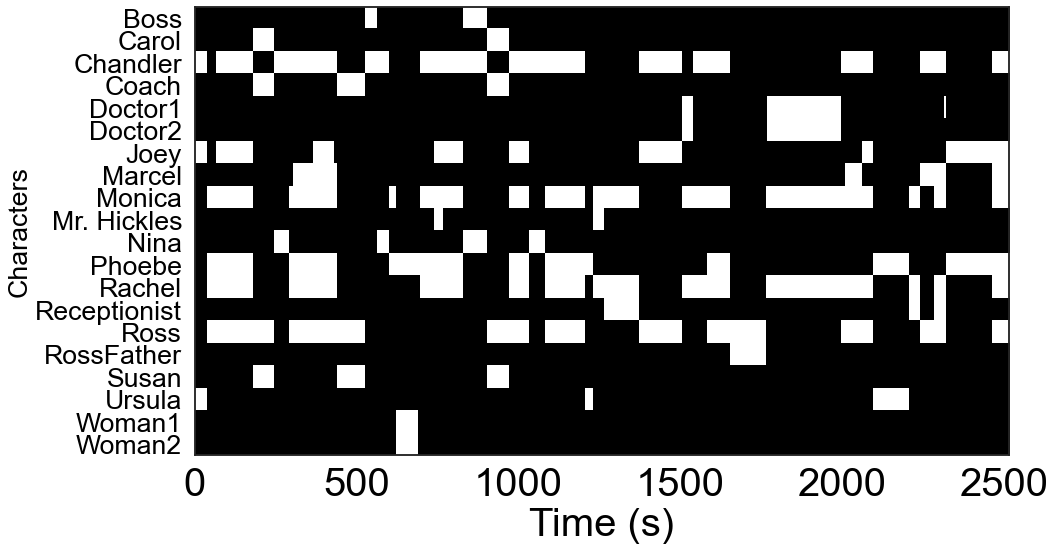

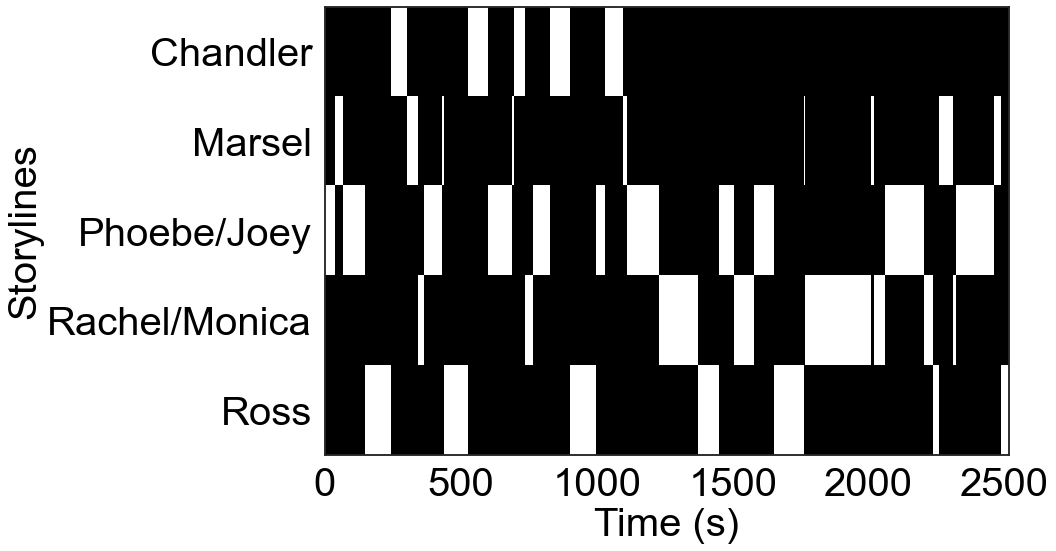

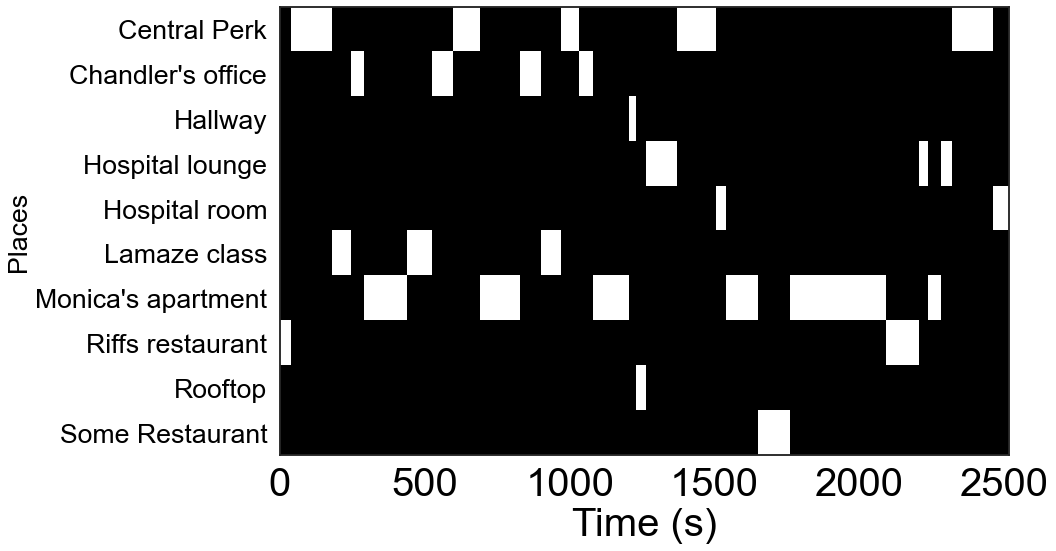

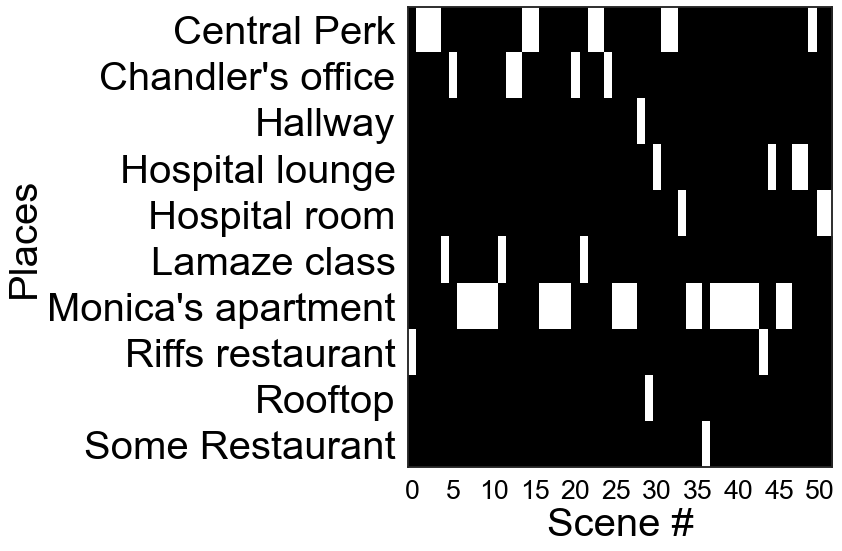

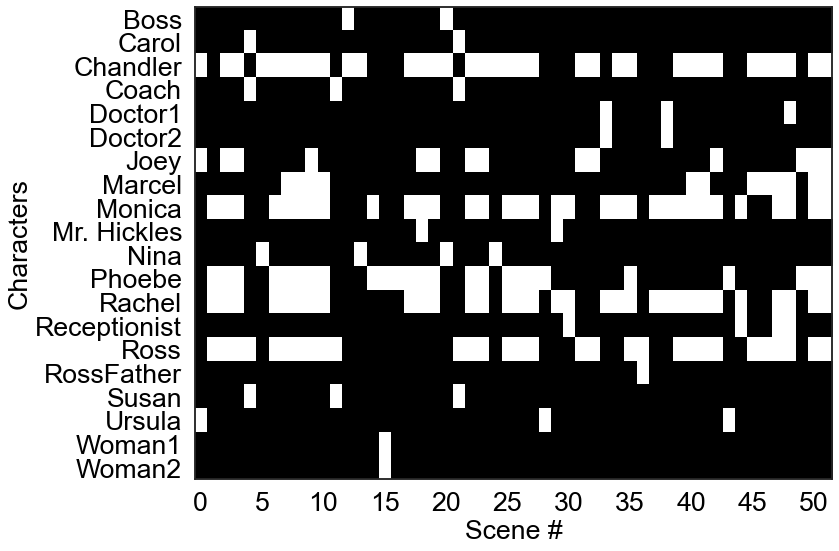

In [49]:
#organize + plot story attributes

a,b,c=list(set(df['Character1'])),list(set(df['Character2'])),list(set(df['Character3']))
d,e,f=list(set(df['Character4'])),list(set(df['Character5'])),list(set(df['Character6']))
g=list(set(df['Character7']))
chars=set(a+b+c+d+e+f+g) #combine
chars = [x for x in chars if str(x) != 'nan']
chars.remove('[end credits 2]')
chars.sort()
print('Characters: %s, total #: %s' %(chars,len(chars)))
#event model list
a=list(set(df['EventModel1']))
#a,b=list(set(df['EventModel1'])),list(set(df['EventModel2']))
ems=set(a) #ems=set(a+b)
ems = [x for x in ems if str(x) != 'nan']
ems.sort()
print('Event models: %s, total #: %s' %(ems,len(ems)))
#place list
places=list(set(df['Place']))
places = [x for x in places if str(x) != 'nan']
places.sort()
print('Places: %s, total #: %s' %(places,len(places)))

cmat,emat,pmat=np.zeros((tsecs,len(chars))),np.zeros((tsecs,len(ems))),np.zeros((tsecs,len(places)))
cmat_sc,pmat_sc=np.zeros((n_ev,len(chars))),np.zeros((n_ev,len(places)))
for i in range(df.shape[0]-1): #up to last moment
    fsec=np.int(df['Secs'][i]) #first second in the event
    lsec=np.int(df['Secs'][i+1]) #last second in the event
    sc_num=int(df['EventModelNum'][i]-1)
    for ii,c in enumerate(chars):
        if df['Character1'][i]==chars[ii]:
            cmat[fsec:lsec,ii]=1
            cmat_sc[sc_num,ii]=1
        if df['Character2'][i]==chars[ii]:
            cmat[fsec:lsec,ii]=1
            cmat_sc[sc_num,ii]=1
        if df['Character3'][i]==chars[ii]:
            cmat[fsec:lsec,ii]=1
            cmat_sc[sc_num,ii]=1
        if df['Character4'][i]==chars[ii]:
            cmat[fsec:lsec,ii]=1
            cmat_sc[sc_num,ii]=1
        if df['Character5'][i]==chars[ii]:
            cmat[fsec:lsec,ii]=1
            cmat_sc[sc_num,ii]=1
        if df['Character6'][i]==chars[ii]:
            cmat[fsec:lsec,ii]=1
            cmat_sc[sc_num,ii]=1
        if df['Character7'][i]==chars[ii]:
            cmat[fsec:lsec,ii]=1
            cmat_sc[sc_num,ii]=1
    for ii,l in enumerate(ems):
        if df['EventModel1'][i]==ems[ii]:
            emat[fsec:lsec,ii]=1
        #if df['EventModel2'][i]==ems[ii]:
        #    emat[fsec:lsec,ii]=1
    for ii,l in enumerate(places):
        if df['Place'][i]==places[ii]:
            pmat[fsec:lsec,ii]=1
            pmat_sc[sc_num,ii]=1

ems[0],ems[1],ems[2],ems[3],ems[4]='Chandler','Marsel','Phoebe/Joey','Rachel/Monica','Ross'
implot(chars,cmat,'Time (s)','Characters',15,8,3) #plot each attribute over time
implot(ems,emat,'Time (s)','Storylines',15,8,0)
implot(places,pmat,'Time (s)','Places',15,8,3)
implot(places,pmat_sc,'Scene #','Places',12,8,1)
implot(chars,cmat_sc,'Scene #','Characters',12,8,2) #plot by scene #

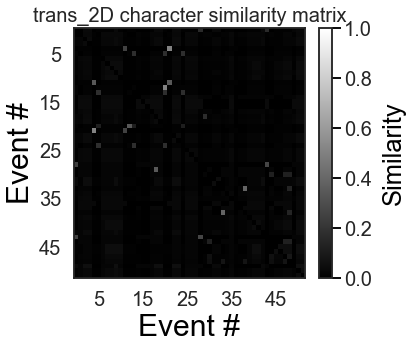

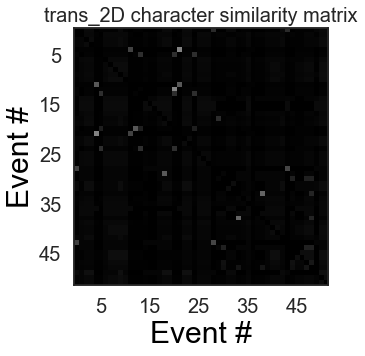

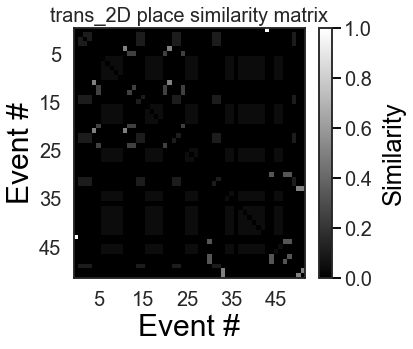

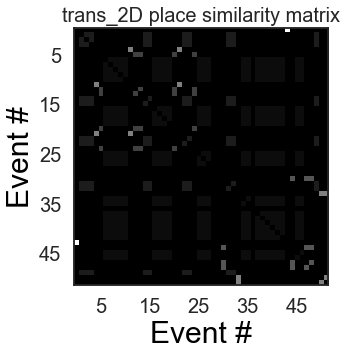

In [50]:
#create character/place transition matrix

fos=30 #48
qq=df['Secs'] #find times of possession changes #include last boundary as of 1/20/25
all_edges=qq[1:].to_numpy().astype(int)

lin_ev=np.linspace(1,n_ev,n_ev)

char_trans,place_trans=np.zeros((n_ev,n_ev)),np.zeros((n_ev,n_ev))
for i in range(n_ev):
    #identify characters in broad scene
    curr_char=np.where(cmat_sc[i,:])[0]
    n_curr_char=len(curr_char)
    #find transitions to other scenes
    for ii in range(n_curr_char):
        curr_trans=np.where(cmat_sc[:,curr_char[ii]])[0]
        curr_trans=curr_trans[curr_trans!=i] #remove identity scene
        buff=np.zeros((len(curr_trans)))+1
        char_trans[i,curr_trans]=char_trans[i,curr_trans]+buff/len(curr_trans)
    
    #identify places in broad scene
    curr_place=np.where(pmat_sc[i,:])[0]
    n_curr_place=len(curr_place)
    #find transitions to other scenes
    for ii in range(n_curr_place):
        curr_trans=np.where(pmat_sc[:,curr_place[ii]])[0]
        curr_trans=curr_trans[curr_trans!=i] #remove identity scene
        buff=np.zeros((len(curr_trans)))+1
        place_trans[i,curr_trans]=place_trans[i,curr_trans]+buff/len(curr_trans)

    #norm each to become PDF
    char_trans[i,:]=char_trans[i,:]/np.nansum(char_trans[i,:])
    if np.nansum(place_trans[i,:])>0:
        place_trans[i,:]=place_trans[i,:]/np.nansum(place_trans[i,:])

plot_trans_mat(char_trans,'trans_2D character similarity matrix',0)
plot_trans_mat(place_trans,'trans_2D place similarity matrix',0)
for i in range(n_ev):
    char_trans[i,i]=math.nan
    place_trans[i,i]=math.nan

In [51]:
#import low-level vis/aud variables
fn=analysis_dir+'lum_mot_all.mat'
mat_contents = scipy.io.loadmat(fn)
lum_sec = mat_contents['lum_sec']
fn=analysis_dir+'upperAud_tr.mat'
mat_contents = scipy.io.loadmat(fn)
aud_sec = mat_contents['upper_sec']

#break into events!
lum_ev,aud_ev,ev_l=np.zeros((n_ev)),np.zeros((n_ev)),np.zeros((n_ev))
for i in range(n_ev):
    if i==0:
        fir=0
    else:
        fir=all_edges[i-1]
    las=all_edges[i]
    lum_ev[i]=np.mean(lum_sec[fir:las])
    aud_ev[i]=np.mean(aud_sec[fir:las])
    ev_l[i]=int(las-fir)

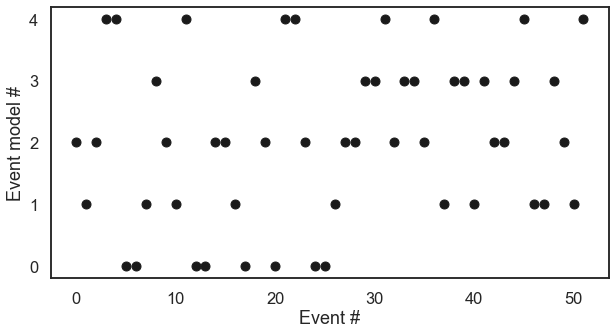

In [52]:
#find event order - do it this way b/c otherwise ST changes w/o EM changes are not read in!
e_o=np.zeros((df.shape[0]-1,2))
for i in range(df.shape[0]-1):
    currsec=np.int(df['Secs'][i])
    qq=np.where(emat[currsec,:]==1)[0] #f
    e_o[i,0],e_o[i,1]=currsec,qq
f, ax = plt.subplots(1,1,figsize = (fs1,fs2/2))
ax.plot(e_o[:,1],'ok')
ax.set_xlabel('Event #')
ax.set_ylabel('Event model #')

df['storylineNum']=np.hstack((e_o[:,1],math.nan)) #log as event model # in df

#find when there are changes in e_o
emchange=np.zeros((n_ev))
emchange[:n_ev-1]=np.diff(e_o[:,1])
emchange[n_ev-1]=1
qq=np.where(emchange!=0)[0]
emchange[qq]=1
sn='pydata/emchange.npy'
np.save(sn,emchange)

qq=np.where(np.diff(df['SceneNum'])==1)[0]
df['STchange_pre'],df['STchange_post']=np.zeros((len(df))),np.zeros((len(df)))
df['STchange_pre'][0]=1
df['STchange_pre'][qq+1]=1
df['STchange_post'][qq]=1
stchange=df['STchange_post'].values
stchange=stchange[:-1]
sn='pydata/stchange.npy'
np.save(sn,stchange)

52
694
(52, 512)


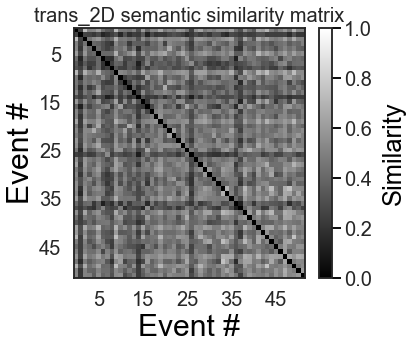

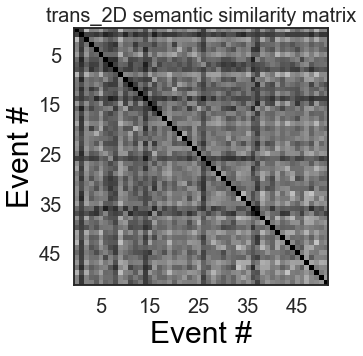

In [53]:
#semantic analysis
#'embed' not working w/ dependencies -- load in from Colab (from 'friendsSemantic.ipynb')
sem_meth=1 #1=full script (default), 2=event summary
llm_to_use=1 #USE or BERT
if sem_meth==1:
    fn,shn,s_col,text_col=xl_dir+'friendsStoryBoard.xlsx','friendsTranscript','Scene','Text'
    sn='pydata/friendsEmbed_fs-'+str(llm_to_use)+'.npy'
elif sem_meth==2:
    fn,shn,s_col,text_col=xl_dir+'friendsStoryBoard.xlsx','FriendsNarrComb','EventModelNum','Explanation'
    sn='pydata/friendsEmbed_summ-'+str(llm_to_use)+'.npy'

df_fs = pd.read_excel(fn,shn,engine='openpyxl') #read in

n_ev=int(np.max(df_fs[s_col])) #last scene
print(n_ev)
if sem_meth==1:
    n_rows=len(df_fs)
elif sem_meth==2:
    n_rows=n_ev+0
print(n_rows)
text = ["" for x in range(n_ev)]
for i in range(n_rows):
    sceneN=int(df_fs[s_col][i]-1)
    txt=df_fs[text_col][i]
    text[sceneN]=text[sceneN]+txt

embeddings_fs=np.load(sn)
if sem_meth==1:
    print(embeddings_fs.shape)
    sem_2d_fs=plot_embed2d(embeddings_fs,'2D semantic matrix, fullScript') #scene-by-scene matrix
elif sem_meth==2:
    sem_2d_fs=plot_embed2d(embeddings_fs,'2D semantic matrix, summary') #scene-by-scene matrix

# read in subject recall data

# subs: 23
s1
s2
s3
s4
s5
s6
s7
s8
s9
s10
s11
s12
s13
s14
s15
s16
s19
s20
s21
s23
s24
s25
s26


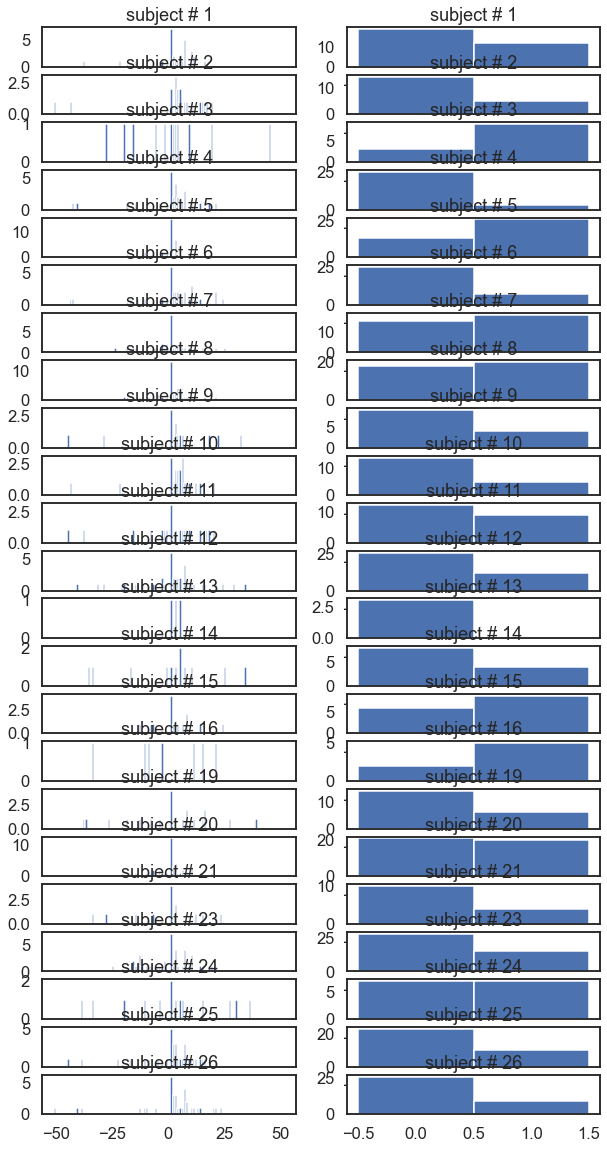

In [54]:
pd.set_option('display.max_rows', 100)
subs=['1','2','3','4','5','6','7','8','9','10',
      '11','12','13','14','15','16','19','20',
      '21','23','24','25','26'] 
nSubs=len(subs)
print('# subs:',nSubs)
fir=int(np.min(df['EventModelNum'])) #first scene
n_st=int(np.max(df['SceneNum'])) #last scene
maxj=n_ev-fir #maximum jump in either direction
js=np.linspace(-maxj,maxj+1,int(maxj*2+2))
xs_jumps,xs_jumps_ems=np.zeros((len(subs),len(js)-1)),np.zeros((len(subs),2))
memo=np.zeros((nSubs,int(n_ev))) #memorability
subsn=['']*len(subs)
states_a=[None]*nSubs
f, ax = plt.subplots(nSubs,2,figsize = (10,20))
recall_l=np.zeros((nSubs,n_ev))
for i in range(nSubs): #loop over all of the subjects
    sheetname='s'+str(subs[i])
    if i<9:
        subsn[i]='0'+subs[i]
    else:
        subsn[i]=''+subs[i]
    print(sheetname)
    dfs = pd.read_excel(xl_dir+'FriendsRecallScoring.xlsx',sheetname,engine='openpyxl')
    dfs['StoryOrderSceneNum']=np.zeros((len(dfs)))
    dfs['EventModel']=np.zeros((len(dfs)))
    for j in range(len(dfs)): #loop over all of the rows from the subjects' recall
        if isinstance(dfs['WhichEvent'][j], str)==1: #if it's a string
            if dfs['WhichEvent'][j][:2].isdigit(): #if digit, to fix '?'
                dfs['WhichEvent'][j]=int(dfs['WhichEvent'][j][:2])
            else:
                dfs['WhichEvent'][j]=math.nan
        
        #note: originally, i'd marked 'interlude' events, but i decided to 
        #remove them and re-order everything. these were labeled in the
        #original way by the scorers, so we need to subtract here to put in new space
        #ALSO i folded two other events together that weren't appropriately separated, 
        #so we need to account for those too. that's what the next 8 lines do.
        if dfs['WhichEvent'][j]>47:
            dfs['WhichEvent'][j]-=4
        elif dfs['WhichEvent'][j]>38:
            dfs['WhichEvent'][j]-=3
        elif dfs['WhichEvent'][j]>36:
            dfs['WhichEvent'][j]-=2
        elif dfs['WhichEvent'][j]>18:
            dfs['WhichEvent'][j]-=1
            
        order_scene=dfs['WhichEvent'][j]
        if order_scene>0: #corresponds to a specific event
            order_scene=int(order_scene)-1 #-1 to align with indices (event 1 goes with index 0)
            memo[i,order_scene]=1
            #find specific event model!
            dfs['EventModel'][j]=int(e_o[order_scene,1])
            dfs['StoryOrderSceneNum'][j]=int(df['SceneNum'][order_scene])
    qq=np.where(dfs.WhichEvent.isna()==0)[0] #find events w/ data
    allsecs=dfs['SecondsOfRecall'][qq] #narrative order
    allevents=dfs['WhichEvent'][qq] #narrative order
    allstevents=dfs['StoryOrderSceneNum'][qq] #narrative order    
    allems=dfs['EventModel'][qq] #narrative order
    states_a[i]=allevents+0 #JWA add
    diff=np.diff(allevents) #find difference from each moment against the prior one
    
    #need to create histogram of transitions, loop through subjects, do more with narratives / order
    qqq=np.where(diff!=0)[0] #where are there non-zero transitions
    ems_pre_trans=allems[qq[qqq]].to_numpy()
    ems_post_trans=allems[qq[qqq+1]].to_numpy()
    allstates_ems=np.hstack((ems_pre_trans,ems_post_trans[:-1]))
    stscene_pre_trans=allstevents[qq[qqq]].to_numpy()
    stscene_post_trans=allstevents[qq[qqq+1]].to_numpy()
    allstates_stscenes=np.hstack((stscene_pre_trans-1,stscene_post_trans[:-1]-1)) #add -1 to put things back in 0-coded space
    scene_pre_trans=allevents[qq[qqq]].to_numpy()
    scene_post_trans=allevents[qq[qqq+1]].to_numpy()
    allstates_scenes=np.hstack((scene_pre_trans-1,scene_post_trans[:-1]-1)) #add -1 to put things back in 0-coded space
    if i==0:
        allems_a=np.hstack((-2,allstates_ems)) #add -2 for recall start
        allems_a=np.hstack((allems_a,-1)) #add -1 for recall end
        allstscenes_a=np.hstack((-2,allstates_stscenes))
        allstscenes_a=np.hstack((allstscenes_a,-1)) 
        allscenes_a=np.hstack((-2,allstates_scenes)) 
        allscenes_a=np.hstack((allscenes_a,-1)) 
    else:
        allems_a=np.hstack((allems_a,-2))
        allems_a=np.hstack((allems_a,allstates_ems))
        allems_a=np.hstack((allems_a,-1))
        allstscenes_a=np.hstack((allstscenes_a,-2))
        allstscenes_a=np.hstack((allstscenes_a,allstates_stscenes))
        allstscenes_a=np.hstack((allstscenes_a,-1))
        allscenes_a=np.hstack((allscenes_a,-2))
        allscenes_a=np.hstack((allscenes_a,allstates_scenes))
        allscenes_a=np.hstack((allscenes_a,-1))
    nzdiff=diff[qqq]
    qqqq=ax[i,0].hist(nzdiff,bins=js)
    ax[i,0].set_title('subject # %s' %subs[i])
    xs_jumps[i,:]=qqqq[0]
    xs_jumps[i,int(maxj)]=math.nan
    nzdiff_ems=ems_post_trans-ems_pre_trans
    nzdiff_ems[np.where(nzdiff_ems!=0)]=1 #if not a zero, call it 1 for across-EM transitions
    qqqqq=ax[i,1].hist(nzdiff_ems,bins=[-0.5,0.5,1.5])
    ax[i,1].set_title('subject # %s' %subs[i])
    xs_jumps_ems[i,:]=qqqqq[0]
    #find recall lengths
    for j in range(n_ev):
        qq=np.where(allevents-1==j)[0]
        if len(qq)>0:
            recall_l[i,j]=int(len(qq))
            
    #output for fMRI analyses
    dfs_out=pd.DataFrame()
    dfs_out['SecondsOfRecall']=allsecs
    dfs_out['WhichEvent']=allevents
    dfs_out['StoryOrderSceneNum']=allstevents
    dfs_out['EventModel']=allems
    fn='pydata/'+sheetname+'_out.csv'
    dfs_out.to_csv(fn,index=False)

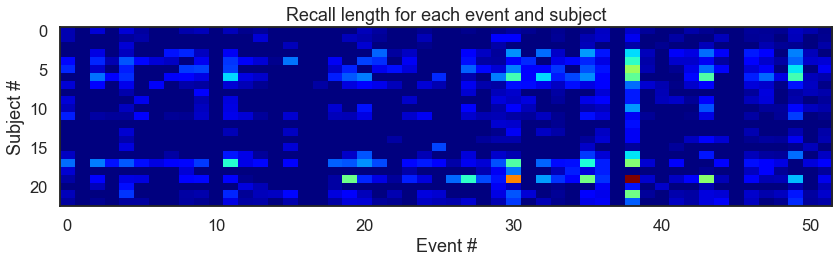

In [55]:
#recall length - all events and subjects
f, ax = plt.subplots(1,1,figsize = (12,4))
ax.imshow(recall_l,interpolation='none',cmap='jet',aspect='auto')
ax.set_ylabel('Subject #')
ax.set_xlabel('Event #')
ax.set_title('Recall length for each event and subject')
f.tight_layout()
fn="figs/recall_lengths_mat.pdf"
plt.savefig(fn, transparent=True)

# load ratings data (causality / importance)

In [56]:
raters=['r1','r2','r3','r4','r5','r6'] #list of raters
lin_ev=np.linspace(1,n_ev,n_ev)
nR=len(raters) # #raters
plot_ind=0     #plot individual raters?
cols2skip = [0,1] #columns to skip when importing data
cols = [i for i in range(n_ev+2) if i not in cols2skip]
icols2skip=[0]
icols = [i for i in range(2) if i not in icols2skip]
cdat_a=np.zeros((n_ev,n_ev,nR)) #matrix for holding causality data
idat_a=np.zeros((n_ev,nR))      #matrix for holding importance data
for i in range(nR): #loop over rater
    fn='ratings/'+raters[i]+'.xlsx' #define filename
    print(fn)
    dfr=pd.read_excel(fn,'CausalityRatings',skiprows=1,usecols=cols) #load data
    dat=dfr.values             #extract relevant numbers from dataframe
    qq=np.where(np.isnan(dat)) #find nan values
    dat[qq]=0                  #assign nan values to zero instead
    cdat_a[:,:,i]=dat          #log all data together
    dfi=pd.read_excel(fn,'ImportanceRatings',skiprows=0,usecols=icols) #load data
    idat=dfi.values #extract relevant numbers from dataframe
    idat_a[:,i]=idat[:,0]
    if plot_ind:
        f, ax = plt.subplots(1,1, figsize = (fs1/4,fs2/4))
        im=ax.imshow(dat,interpolation='none',cmap=cm,aspect='auto')
        ax.set_xlabel('Scene #')
        ax.set_ylabel('Scene #')

ratings/r1.xlsx
ratings/r2.xlsx
ratings/r3.xlsx
ratings/r4.xlsx
ratings/r5.xlsx
ratings/r6.xlsx


only 1 rater assigned 49 scene combos


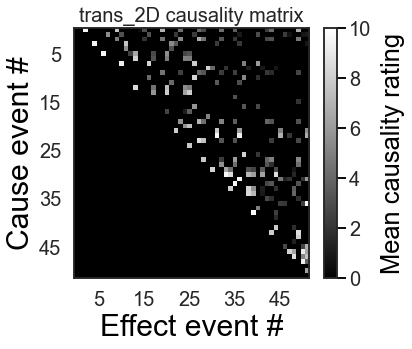

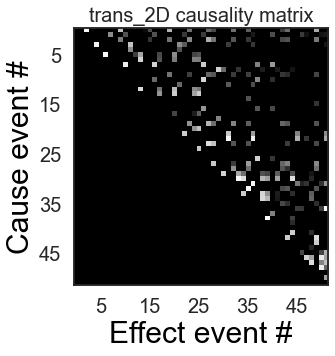

In [57]:
#plot 2-D (scene x scene) matrix of mean causality ratings
cdat_a_m=np.zeros((n_ev,n_ev))
only_one_rater=0
for i in range(n_ev):
    for ii in range(n_ev):
        if np.sum(cdat_a[i,ii,:]>0)>1: #only count if >1 rater gave it non-zero number
            cdat_a_m[i,ii]=np.mean(cdat_a[i,ii,:])
        elif np.sum(cdat_a[i,ii,:]>0)>0:
            only_one_rater+=1

print('only 1 rater assigned %s scene combos' %only_one_rater)
for i in range(n_ev):
    cdat_a_m[i,i]=0 #math.nan #zero out diagonal (for viz)
    
plot_trans_mat(cdat_a_m,'trans_2D causality matrix',1)

#nan out self-referential diagonal
for i in range(cdat_a.shape[0]):
    for j in range(cdat_a.shape[0]):
        if i==j:
            cdat_a[i,j,:]=np.nan

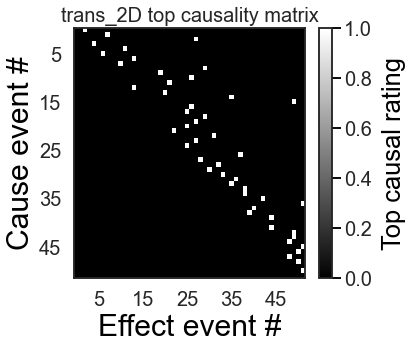

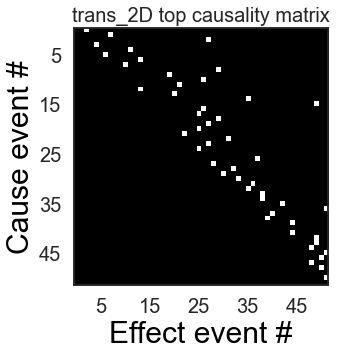

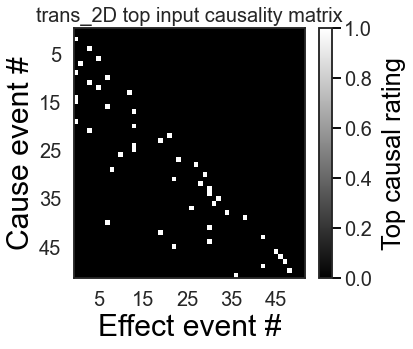

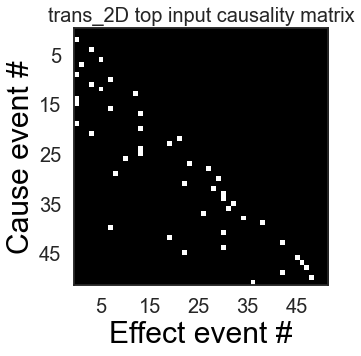

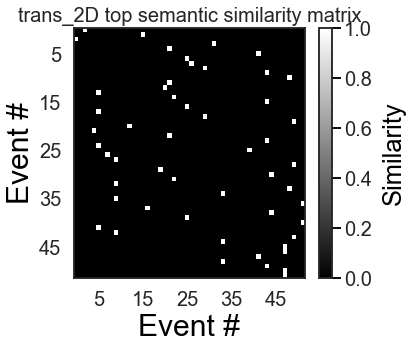

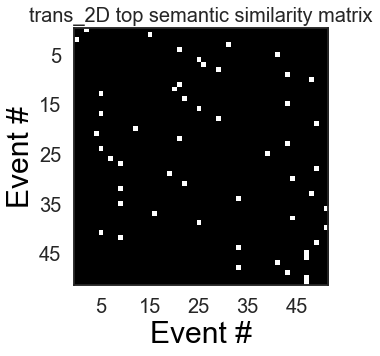

In [58]:
#find top causal match
tcdat_a_m=np.zeros((n_ev,n_ev))
for i in range(n_ev):
    qq=np.where(cdat_a_m[i,:]==np.max(cdat_a_m[i,:]))[0]
    if np.max(cdat_a_m[i,:])>0: #only assign if this isn't completely blank
        tcdat_a_m[i,qq[0]]=1

#find top INPUT causal match
ticdat_a_m=np.zeros((n_ev,n_ev))
for i in range(n_ev):
    qq=np.where(cdat_a_m[:,i]==np.max(cdat_a_m[:,i]))[0]
    if np.max(cdat_a_m[:,i])>0: #only assign if this isn't completely blank
        ticdat_a_m[i,qq[0]]=1

#find top semantic match
tsem_2d_fs=np.zeros((n_ev,n_ev))
for i in range(n_ev):
    qq=np.where(sem_2d_fs[i,:]==np.max(sem_2d_fs[i,:]))[0]
    if np.max(sem_2d_fs[i,:])>0: #only assign if this isn't completely blank
        tsem_2d_fs[i,qq[0]]=1

plot_trans_mat(tcdat_a_m,'trans_2D top causality matrix',4)
plot_trans_mat(ticdat_a_m,'trans_2D top input causality matrix',4)
plot_trans_mat(tsem_2d_fs,'trans_2D top semantic similarity matrix',0)

In [59]:
#examine across-rater reliability
xrater_r=np.zeros((cdat_a.shape[2]))
for i in range(cdat_a.shape[2]): #loop over raters
    ids=[]
    for j in range(cdat_a.shape[2]):
        if i!=j:
            ids=np.hstack([ids,int(j)])
    ids=ids.astype(int)
    avg_group=np.mean(cdat_a[:,:,ids],2).flatten()
    heldout=cdat_a[:,:,i].flatten()

    qq=ma.corrcoef(ma.masked_invalid(avg_group), ma.masked_invalid(heldout))
    xrater_r[i]=qq[1,0]

print('All scores based on holdout method:',xrater_r)
print('Mean:',np.mean(xrater_r))
print('Median:',np.median(xrater_r))
# split half reliability
first_half=np.mean(cdat_a[:,:,:nR//2],2).flatten()
second_half=np.mean(cdat_a[:,:,nR//2:],2).flatten()
qq=ma.corrcoef(ma.masked_invalid(first_half), ma.masked_invalid(second_half))
print('Split-half reliability:',qq[1,0])

All scores based on holdout method: [0.88008854 0.77128385 0.75361725 0.69914899 0.82839309 0.85233935]
Mean: 0.7974785119693545
Median: 0.7998384667256382
Split-half reliability: 0.8799504503254102


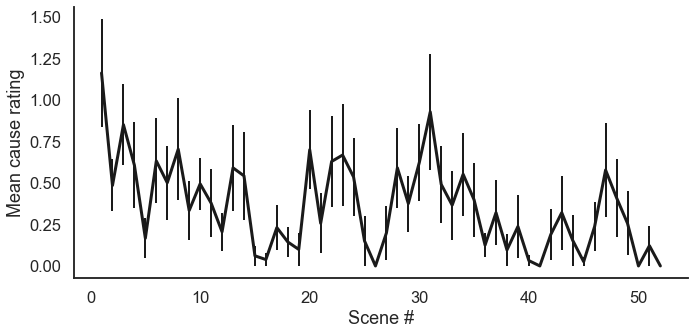

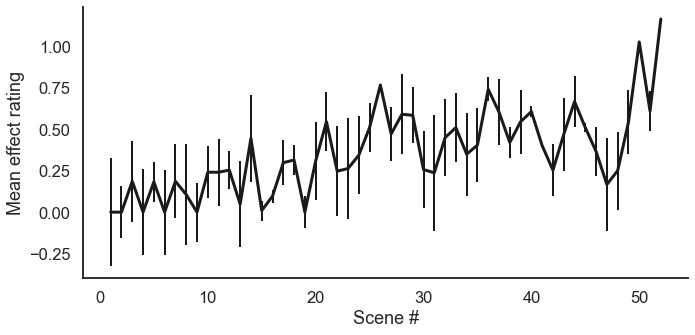

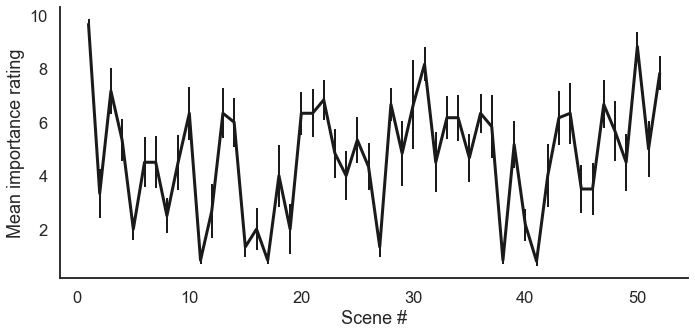

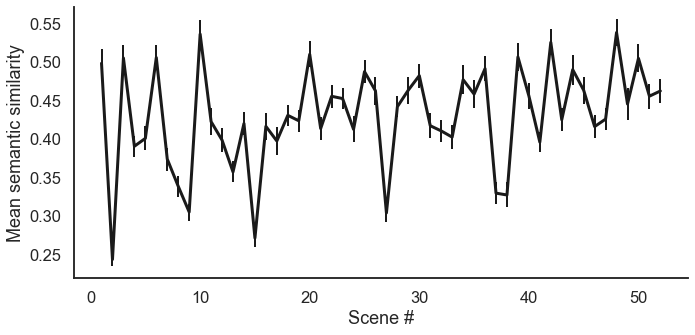

In [60]:
#plot some attributes by scene
y_caus,err_caus=plotscenev(cdat_a_m,'Mean cause rating',figf+"scene_causality.pdf",2,1)
y_eff,err_eff=plotscenev(cdat_a_m,'Mean effect rating',figf+"scene_causality.pdf",2,0)
y_imp,err_imp=plotscenev(idat_a,'Mean importance rating',figf+"scene_importance.pdf",2,1)
y_sem,err_sem=plotscenev(sem_2d_fs,'Mean semantic similarity',figf+"scene_semantic.pdf",2,1)

Importance rating, pearson r = 0.644, p = 0.000, spearman r = 0.678, p = 0.000
Semantic similarity, pearson r = 0.468, p = 0.000, spearman r = 0.458, p = 0.001


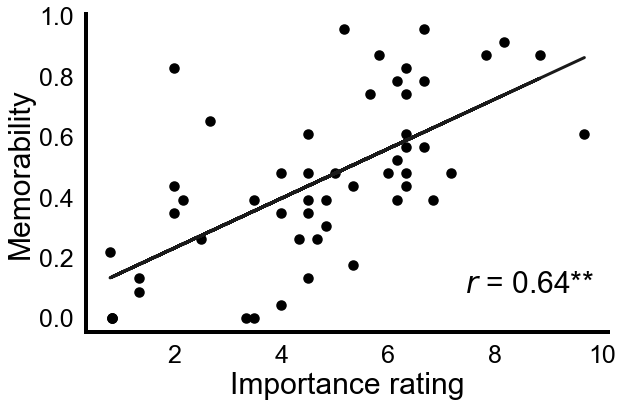

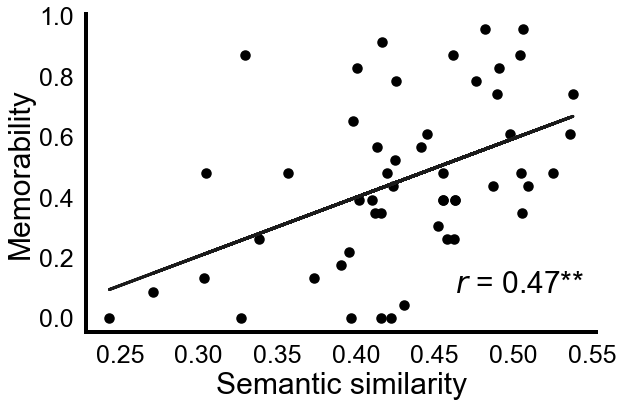

In [61]:
quicksp(np.nanmean(idat_a,1),np.nanmean(memo,0),'Importance rating','Memorability',figf+"scene_impXmemo.pdf")
quicksp(np.nanmean(sem_2d_fs,1),np.nanmean(memo,0),'Semantic similarity','Memorability',figf+"scene_semXmemo"+str(sem_meth)+".pdf")

In [62]:
#create semantic+causal networks
perc_thr=80 #80
#causal
blah2=cdat_a_m[np.where(np.isnan(cdat_a_m)==0)]
causthr=np.percentile(blah2,perc_thr) #2 #minimum causality rating to keep'
print('caus thresh:',causthr)
#tcausal
blah2=tcdat_a_m[np.where(np.isnan(tcdat_a_m)==0)]
tcausthr=np.percentile(blah2,perc_thr) #2 #minimum causality rating to keep'
print('top caus thresh:',tcausthr)
#semantic
blah2=sem_2d_fs[np.where(np.isnan(sem_2d_fs)==0)]
semthr=np.percentile(blah2,perc_thr) #2 #minimum causality rating to keep'
print('top sem thresh:',semthr)

np.save('pydata/semthr-%s.npy' %perc_thr,semthr)

G_caus,ew_caus,cmap_caus=create_network(cdat_a_m,causthr,e_o)
G_tcaus,ew_tcaus,cmap_tcaus=create_network(tcdat_a_m,tcausthr,e_o)
G_caus_rev,ew_caus_rev,cmap_caus_rev=create_network(cdat_a_m.T,causthr,e_o) #use same thresh as caus
G_sem,ew_sem,cmap_sem=create_network(sem_2d_fs,semthr,e_o)

ld_ang=0
if ld_ang:
    ln='pydata/ang_2d.npy'
    exmat=np.load(ln)
    blah2=tcdat_a_m[np.where(np.isnan(tcdat_a_m)==0)]
    neurthr=np.percentile(blah2,perc_thr) #2 #minimum causality rating to keep'
    print('top neur thresh:',neurthr)
    G_neur,ew_neur,cmap_neur=create_network(exmat,neurthr,e_o)
    G2_neur=nx.DiGraph(G_neur) #must convert to digraph for eigenvector centrality
    ln='pydata/ang_2d_a.npy'
    exmat_a=np.load(ln)

caus thresh: 0.0
top caus thresh: 0.0
top sem thresh: 0.536621622687249


In [63]:
#assign network attributes to variables

#CAUSALITY
G2_caus=nx.DiGraph(G_caus) #must convert to digraph for eigenvector centrality
b_cent=nx.betweenness_centrality(G2_caus, weight= 'weight')
#### instead of in degree and out degree, let's use sum of ROW for out degree
#### and sum of column for in degree!!
y_inw=np.nanmean(cdat_a_m,0)
y_outw=np.nanmean(cdat_a_m,1)
y_degw=(y_inw+y_outw)

#don't use variables in this section - they don't allow factoring in weights
deg_cent=nx.degree_centrality(G2_caus)
in_cent=nx.in_degree_centrality(G2_caus)
out_cent=nx.out_degree_centrality(G2_caus)
y_b_cent=[float(x) for x in list(b_cent.values())]
y_deg_cent=[float(x) for x in list(deg_cent.values())]
y_in_cent=[float(x) for x in list(in_cent.values())]
y_out_cent=[float(x) for x in list(out_cent.values())]

G2_sem=nx.DiGraph(G_sem) #must convert to digraph for eigenvector centrality
b_cent_sem=nx.betweenness_centrality(G2_sem, weight= 'weight')

#don't use variables in this section - they don't allow factoring in weights
deg_cent_sem=nx.degree_centrality(G2_sem)
y_b_cent_sem=[float(x) for x in list(b_cent_sem.values())]
y_deg_cent_sem=[float(x) for x in list(deg_cent_sem.values())]

node_sz_meth=2 #1=use node degree,2=importance
if node_sz_meth==1:
    outc=y_deg_cent
    outc_sem=y_deg_cent_sem
elif node_sz_meth==2:
    outc=y_imp
    outc_sem=y_imp

node_szs,node_szs_sem=np.zeros((n_ev)),np.zeros((n_ev))
for i in range(n_ev):
    node_szs[i]=np.divide(outc[i],np.sum(outc))
    node_szs_sem[i]=np.divide(outc_sem[i],np.sum(outc_sem))
node_szs=np.divide(np.around(np.multiply(node_szs,100)),100) #keep 2 decimals
node_szs_sem=np.divide(np.around(np.multiply(node_szs_sem,100)),100) #keep 2 decimals
node_szs_neur=node_szs+0
if node_sz_meth==2:
    print('% importance of each scene, normalized:',node_szs)
    
sn='pydata/y_deg_cent.npy'
np.save(sn,y_deg_cent)
sn='pydata/y_in_cent.npy'
np.save(sn,y_in_cent)
sn='pydata/y_out_cent.npy'
np.save(sn,y_out_cent)
sn='pydata/y_deg_cent_sem.npy'
np.save(sn,y_deg_cent_sem)
sn='pydata/y_imp.npy'
np.save(sn,y_imp)

% importance of each scene, normalized: [0.04 0.01 0.03 0.02 0.01 0.02 0.02 0.01 0.02 0.03 0.   0.01 0.03 0.02
 0.01 0.01 0.   0.02 0.01 0.03 0.03 0.03 0.02 0.02 0.02 0.02 0.01 0.03
 0.02 0.03 0.03 0.02 0.03 0.03 0.02 0.03 0.02 0.   0.02 0.01 0.   0.02
 0.03 0.03 0.01 0.01 0.03 0.02 0.02 0.04 0.02 0.03]


Causal network centrality, pearson r = 0.377, p = 0.006, spearman r = 0.430, p = 0.001
Inbound weights (sum), causal network, pearson r = 0.332, p = 0.016, spearman r = 0.259, p = 0.064
Outbound weights (sum), causal network, pearson r = 0.012, p = 0.932, spearman r = 0.025, p = 0.861
Semantic network centrality, pearson r = 0.416, p = 0.002, spearman r = 0.408, p = 0.003
Importance, pearson r = 0.733, p = 0.000, spearman r = 0.738, p = 0.000
Importance, pearson r = 0.259, p = 0.064, spearman r = 0.175, p = 0.214
Importance, pearson r = 0.401, p = 0.003, spearman r = 0.363, p = 0.008
Importance, pearson r = 0.431, p = 0.001, spearman r = 0.446, p = 0.001


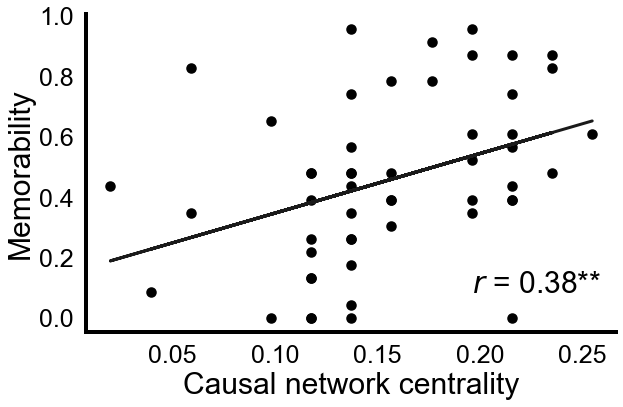

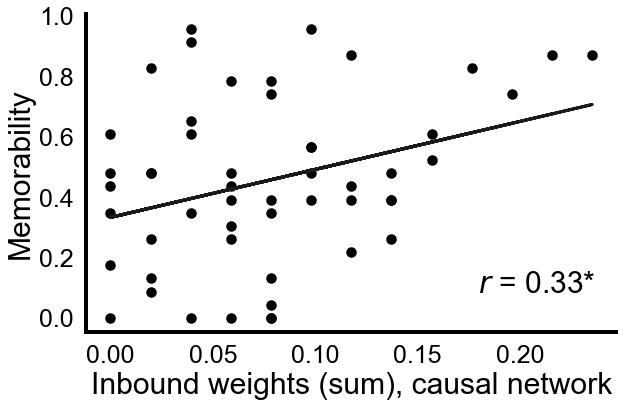

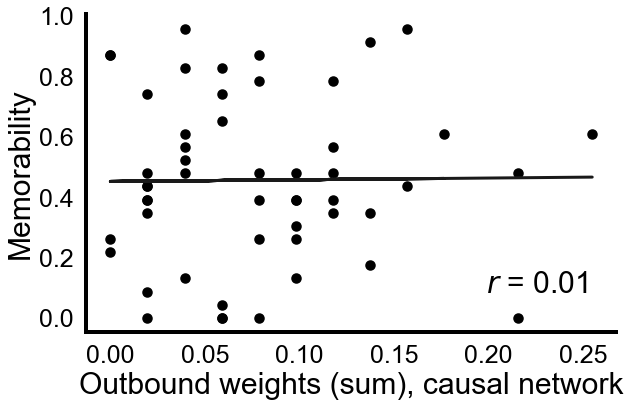

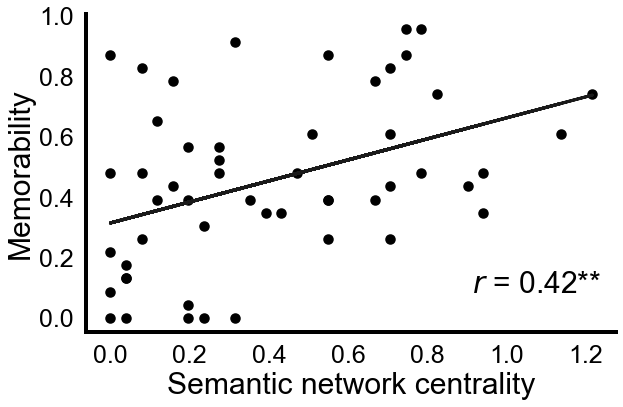

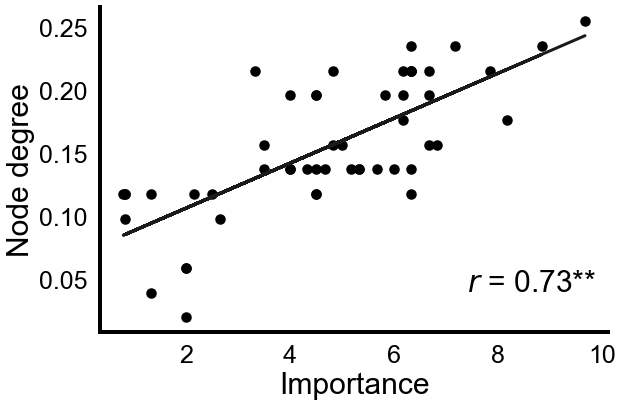

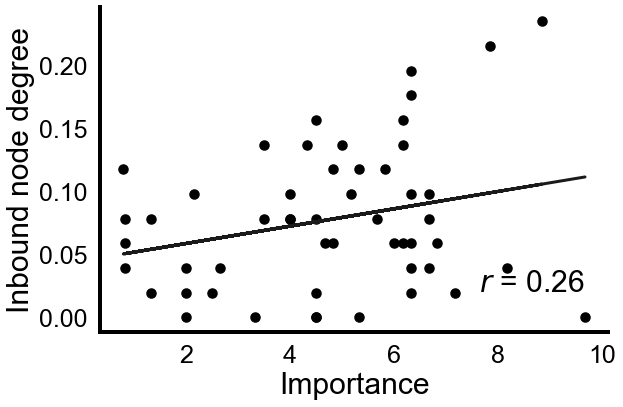

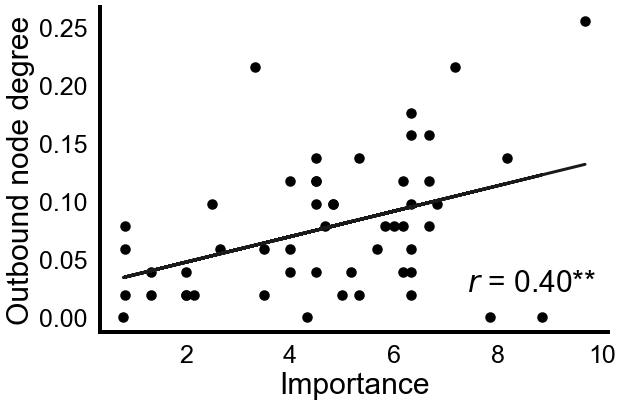

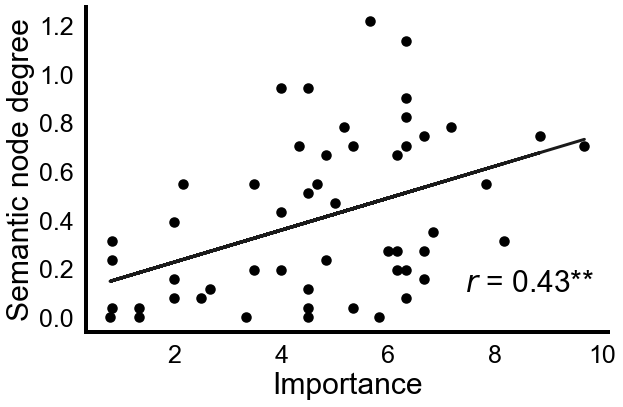

In [64]:
quicksp(y_deg_cent,np.nanmean(memo,0),'Causal network centrality','Memorability',figf+"scene_degcentXmemo.pdf")
quicksp(y_in_cent,np.nanmean(memo,0),'Inbound weights (sum), causal network','Memorability',figf+"scene_incentXmemo.pdf")
quicksp(y_out_cent,np.nanmean(memo,0),'Outbound weights (sum), causal network','Memorability',figf+"scene_outcentXmemo.pdf")
quicksp(y_deg_cent_sem,np.nanmean(memo,0),'Semantic network centrality','Memorability',figf+"scene_degcentsemXmemo"+str(sem_meth)+".pdf")

quicksp(y_imp,y_deg_cent,'Importance','Node degree',figf+"scene_impXdegcent.pdf")
quicksp(y_imp,y_in_cent,'Importance','Inbound node degree',figf+"scene_impXincent.pdf")
quicksp(y_imp,y_out_cent,'Importance','Outbound node degree',figf+"scene_impXoutcent.pdf")
quicksp(y_imp,y_deg_cent_sem,'Importance','Semantic node degree',figf+"scene_impXdegcentsem.pdf")

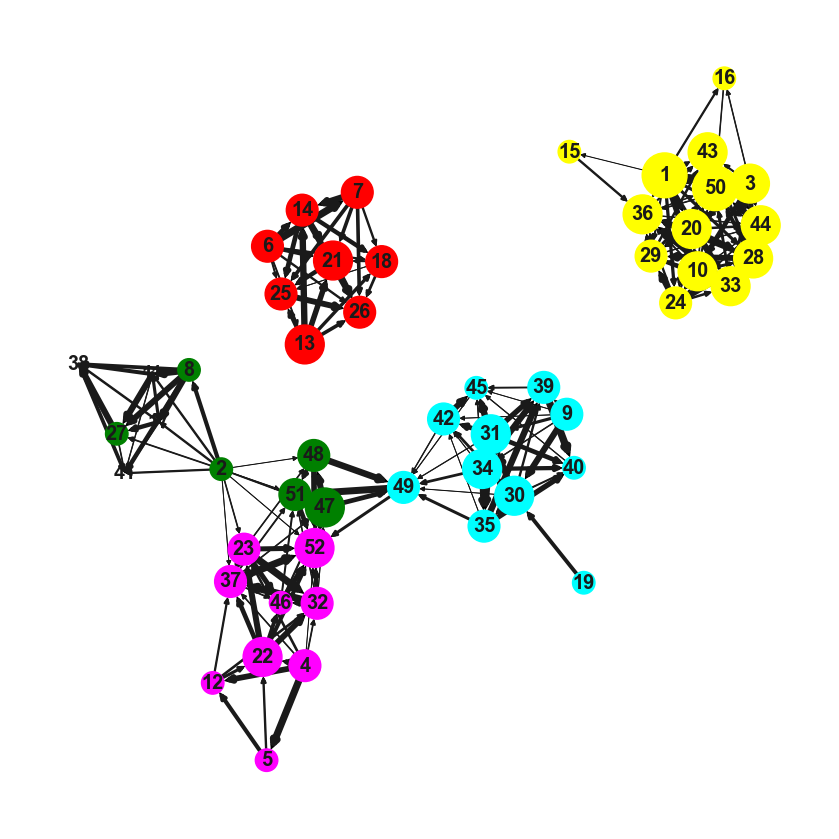

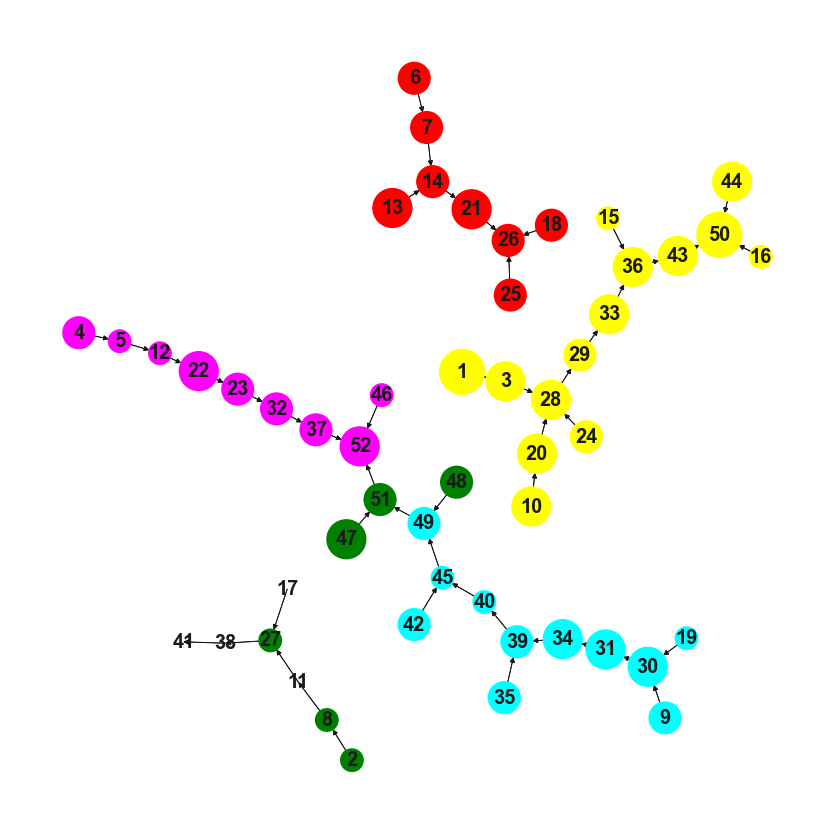

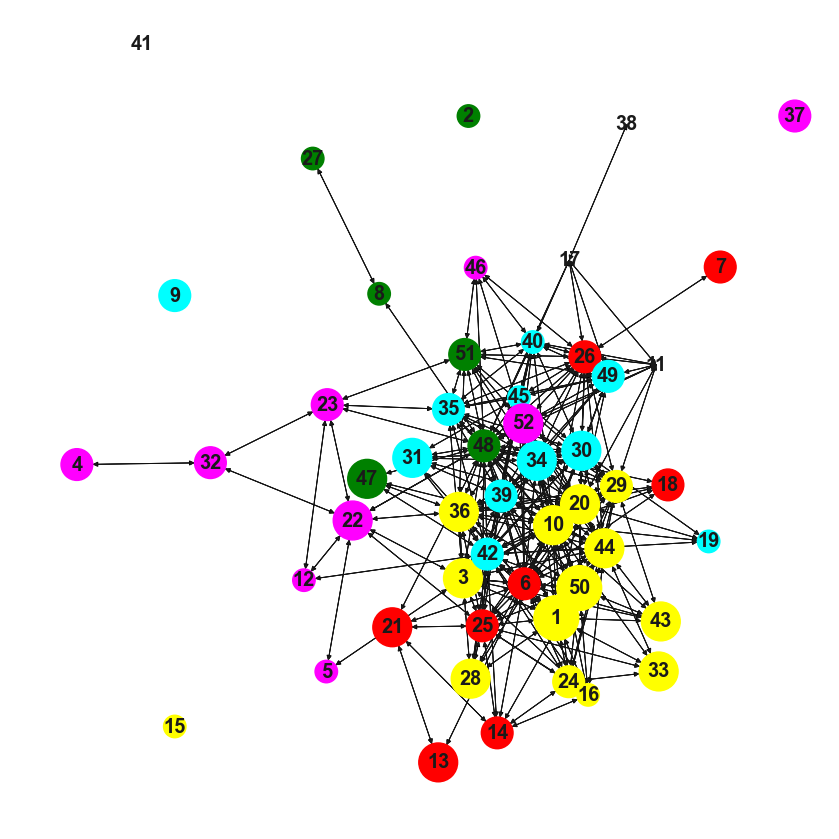

In [65]:
#plot network graphs 
no_mult=50000
ed_mult=0.75
network_plot(G_caus,ew_caus,node_szs,ed_mult,"causality_trans_graph",20)
network_plot(G_tcaus,ew_tcaus,node_szs,ed_mult,"top_causality_trans_graph",20)
network_plot(G_sem,ew_sem,node_szs_sem,ed_mult,"semantic_trans_graph"+str(sem_meth),20)
if ld_ang:
    network_plot(G_neur,ew_neur,node_szs_neur,ed_mult,"neur_sim_trans_graph"+str(sem_meth),20)

In [66]:
#create network of costs (rather than weights)
#use Dijkstra (1959) inverse weighting
q=np.where(cdat_a_m>0)
inv_cdat_a_m=cdat_a_m+0
inv_cdat_a_m[q]=1/cdat_a_m[q]
print(inv_cdat_a_m[:5,:5])
G_invw_caus,ew_invw_caus,cmap_invw_caus=create_network(inv_cdat_a_m,0,e_o)

#find all possible path lengths 
wpathl_a,pl_max=np.zeros((n_ev-1,n_ev-1)),1
for i in range(n_ev-1):
    for ii in range(n_ev-1):
        if i!=ii:
            source=str(i) #events start from 1
            targ=str(ii)
            try:
                buff=nx.shortest_path_length(G_invw_caus,source=source,target=targ,weight='weight')
                wpathl_a[i,ii]=buff
            except:
                wpathl_a[i,ii]=pl_max

wpathl_a=wpathl_a.flatten() #can plot if we want

#find path length between successive states!!!!
wpathl,dl=np.zeros((n_ev)),0
for i in range(n_ev-1):
    source=str(i+1) #events start from 1
    targ=str(i+1+1)
    try:
        buff=nx.shortest_path_length(G_invw_caus,source=source,target=targ,weight='weight')
        wpathl[i]=buff
    except:
        wpathl[i]=pl_max
    else:
        print(f"Shortest weighted path length from {source} to {targ}: {wpathl[i]}")
        dl+=1

wpathl[n_ev-1]=pl_max #set final boundary into credits
print('%s have some kind of link!' %dl)

sn='pydata/wpathl.npy'
np.save(sn,wpathl)

print(wpathl)

[[0.         0.         0.10344828 0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.10526316]
 [0.         0.         0.         0.         0.        ]]
Shortest weighted path length from 4 to 5: 0.10526315789473684
Shortest weighted path length from 6 to 7: 0.10344827586206898
Shortest weighted path length from 13 to 14: 0.11764705882352941
Shortest weighted path length from 22 to 23: 0.125
Shortest weighted path length from 25 to 26: 0.12765957446808512
Shortest weighted path length from 28 to 29: 0.12765957446808512
Shortest weighted path length from 30 to 31: 0.12244897959183675
Shortest weighted path length from 34 to 35: 0.125
Shortest weighted path length from 39 to 40: 0.10169491525423728
Shortest weighted path length from 43 to 44: 0.125
Shortest weighted path length from 46 to 47: 0.3529411764705882
Shortest weighted path length from 47 to 

Full model
0.5150131332764749
[ 0.          0.09968844 -0.91684071  0.12172651 -1.03856721  0.14451564]
Importance only: 0.4152723846736305, [0.         0.08221365]
Importance + cnd: 0.4350759099885986, [ 0.          0.10155657 -1.08114567]
Importance + in-bound cnd: 0.444594033876167, [0.         0.0763638  0.84777034]
Importance + out-bound cnd: 0.48765948934503733, [ 0.          0.09725215 -1.3682741 ]
Importance + snd: 0.4385949403138034, [0.         0.072898   0.14166187]
Importance + cnd + snd: 0.46814190050170346, [ 0.          0.09496789 -1.34371695  0.17163035]
In-bound cnd: 0.1102872850516674, [0.         1.58821469]
In-bound cnd + out-bound cnd: 0.17758306563449766, [0.         2.50088654 1.50015075]
(52, 6)
All components: 0.5150131332764749, [ 8.21770561e-02  1.37441806e-01  7.97368832e-01 -1.14167345e+00
  5.01005788e-31  0.00000000e+00]
First component: 0.416934670975444, [0.         0.08217706]
First 2 components: 0.43883421655166377, [0.         0.08217706 0.13744181]


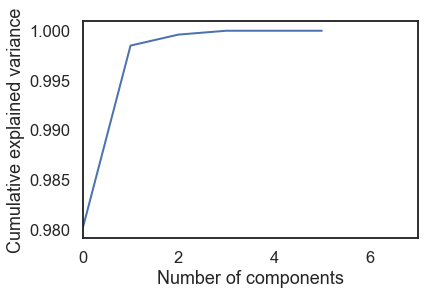

In [67]:
#multiple regression predicting memorability
X_f=np.vstack((np.ones(n_ev),y_imp,y_deg_cent,y_in_cent,y_out_cent,y_deg_cent_sem)).T
y=np.nanmean(memo,0)
full = LinearRegression().fit(X_f, y)
print('Full model')
print(full.score(X_f, y))
print(full.coef_)

X=np.vstack((np.ones(n_ev),y_imp)).T
mod = LinearRegression().fit(X, y)
print('Importance only: %s, %s' %(mod.score(X,y),mod.coef_))

X=np.vstack((np.ones(n_ev),y_imp,y_deg_cent)).T
mod = LinearRegression().fit(X, y)
print('Importance + cnd: %s, %s' %(mod.score(X,y),mod.coef_))

X=np.vstack((np.ones(n_ev),y_imp,y_in_cent)).T
mod = LinearRegression().fit(X, y)
print('Importance + in-bound cnd: %s, %s' %(mod.score(X,y),mod.coef_))

X=np.vstack((np.ones(n_ev),y_imp,y_out_cent)).T
mod = LinearRegression().fit(X, y)
print('Importance + out-bound cnd: %s, %s' %(mod.score(X,y),mod.coef_))

X=np.vstack((np.ones(n_ev),y_imp,y_deg_cent_sem)).T
mod = LinearRegression().fit(X, y)
print('Importance + snd: %s, %s' %(mod.score(X,y),mod.coef_))

X=np.vstack((np.ones(n_ev),y_imp,y_deg_cent,y_deg_cent_sem)).T
mod = LinearRegression().fit(X, y)
print('Importance + cnd + snd: %s, %s' %(mod.score(X,y),mod.coef_))

X=np.vstack((np.ones(n_ev),y_in_cent)).T
mod = LinearRegression().fit(X, y)
print('In-bound cnd: %s, %s' %(mod.score(X,y),mod.coef_))

X=np.vstack((np.ones(n_ev),y_in_cent,y_out_cent)).T
mod = LinearRegression().fit(X, y)
print('In-bound cnd + out-bound cnd: %s, %s' %(mod.score(X,y),mod.coef_))

#PCA
print(X_f.shape)
X_std=StandardScaler().fit_transform(X_f)

sklearn_pca=PCA(n_components=5)
#X_Train=sklearn_pca.fit_transform(X_std)
pca = PCA().fit(X_f)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlim(0,7,1)
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')

pca = PCA().fit_transform(X_f)
mod = LinearRegression().fit(pca, y)
print('All components: %s, %s' %(mod.score(pca,y),mod.coef_))

X=np.vstack((np.ones(n_ev),pca[:,0])).T
mod = LinearRegression().fit(X, y)
print('First component: %s, %s' %(mod.score(X,y),mod.coef_))

X=np.vstack((np.ones(n_ev),pca[:,0],pca[:,1])).T
mod = LinearRegression().fit(X, y)
print('First 2 components: %s, %s' %(mod.score(X,y),mod.coef_))

X=np.vstack((np.ones(n_ev),pca[:,0],pca[:,1],pca[:,2])).T
mod = LinearRegression().fit(X, y)
print('First 3 components: %s, %s' %(mod.score(X,y),mod.coef_))

X=np.vstack((np.ones(n_ev),pca[:,0],pca[:,1],pca[:,2],pca[:,3])).T
mod = LinearRegression().fit(X, y)
print('First 4 components: %s, %s' %(mod.score(X,y),mod.coef_))

## transition analyses

In [68]:
#find node sizes
em_s=len(ems)+2
node_szs_trans=np.zeros((em_s))
for i in range(em_s):
    node_szs_trans[i]=np.divide(np.count_nonzero(allems_a==i-2),len(allems_a))
node_szs_trans=np.divide(np.around(np.multiply(node_szs_trans,100)),100) #keep 2 decimals
print('% time in each EM:',node_szs_trans)

stsc_s=n_st+2 #num st event states
node_stev_szs=np.zeros((stsc_s))
for i in range(stsc_s):
    node_stev_szs[i]=np.divide(np.count_nonzero(allstscenes_a==i-2),len(allstscenes_a))
node_stev_szs=np.divide(np.around(np.multiply(node_stev_szs,100)),100) #keep 2 decimals
print('% time in each st event:',node_stev_szs)

sc_s=n_ev+2 #num event states
node_ev_szs=np.zeros((sc_s))
for i in range(sc_s):
    node_ev_szs[i]=np.divide(np.count_nonzero(allscenes_a==i-2),len(allscenes_a))
node_ev_szs=np.divide(np.around(np.multiply(node_ev_szs,100)),100) #keep 2 decimals
print('% time in each event:',node_ev_szs)

% time in each EM: [0.02 0.02 0.11 0.1  0.3  0.27 0.17]
% time in each st event: [0.02 0.02 0.02 0.03 0.03 0.02 0.06 0.03 0.02 0.02 0.01 0.04 0.03 0.02
 0.03 0.02 0.04 0.01 0.04 0.04 0.03 0.03 0.05 0.03 0.04 0.06 0.03 0.01
 0.03 0.06 0.03 0.05]
% time in each event: [0.02 0.02 0.02 0.   0.02 0.01 0.03 0.02 0.01 0.01 0.02 0.03 0.   0.03
 0.02 0.02 0.   0.01 0.   0.   0.02 0.02 0.03 0.02 0.01 0.01 0.02 0.01
 0.01 0.03 0.01 0.04 0.04 0.02 0.02 0.03 0.02 0.03 0.03 0.   0.04 0.02
 0.01 0.02 0.02 0.03 0.01 0.   0.03 0.03 0.03 0.03 0.02 0.03]


In [69]:
t_thr=1 #min # transitions to keep
trans_mat=np.zeros((em_s,em_s))
for i in range(em_s):
    qq=np.where(allems_a==i-2)[0]
    if i-2!=-1:
        temp=allems_a[qq+1]
        for j in range(em_s):
            if np.count_nonzero(temp==j-2)>t_thr: #threshold based on t_thr to reduce network size
                qqq=np.divide(np.count_nonzero(temp==j-2),len(temp))
                trans_mat[i,j]=qqq
trans_mat=np.divide(np.around(np.multiply(trans_mat,100)),100)

trans_stev_mat=np.zeros((stsc_s,stsc_s))
for i in range(stsc_s):
    qq=np.where(allstscenes_a==i-2)[0]
    if i-2!=-1:
        temp=allstscenes_a[qq+1]
        for j in range(stsc_s):
            if np.count_nonzero(temp==j-2)>t_thr:
                qqq=np.divide(np.count_nonzero(temp==j-2),len(temp))
                trans_stev_mat[i,j]=qqq
trans_stev_mat=np.divide(np.around(np.multiply(trans_stev_mat,100)),100)

trans_ev_mat=np.zeros((sc_s,sc_s))
for i in range(sc_s):
    qq=np.where(allscenes_a==i-2)[0]
    if i-2!=-1:
        temp=allscenes_a[qq+1]
        for j in range(sc_s):
            if np.count_nonzero(temp==j-2)>t_thr:
                qqq=np.divide(np.count_nonzero(temp==j-2),len(temp))
                trans_ev_mat[i,j]=qqq
trans_ev_mat=np.divide(np.around(np.multiply(trans_ev_mat,100)),100)

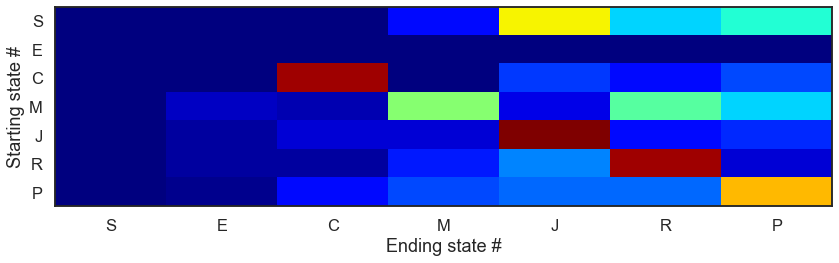

In [70]:
slabs=['S','E','C','M','J','R','P'] #'S' and 'E' are start and end of recall
f, ax = plt.subplots(1,1,figsize = (12,4))
ax.imshow(trans_mat,interpolation='none',cmap='jet',aspect='auto')
ax.set_ylabel('Starting state #')
ax.set_xlabel('Ending state #')
ax.set_yticks(np.arange(len(slabs)))
ax.set_yticklabels(slabs)
ax.set_xticks(np.arange(len(slabs)))
ax.set_xticklabels(slabs)#,rotation = 15)
f.tight_layout()
fn="figs/recall_em_trans_mat.pdf"
plt.savefig(fn, transparent=True)

In [71]:
nonz=np.nansum(trans_stev_mat,axis=0)+np.nansum(trans_stev_mat,axis=1) #add rows/columns
qq=np.where(nonz!=0)[0] #find where non-zero

slabs_stev,trans_stev_mat2,node_stev_szs2,stev_l,j=[],np.zeros((len(qq),len(qq))),np.zeros((len(qq))),np.zeros(len(qq)),0
for i in range(stsc_s):
    if any(x == i for x in qq):
        trans_stev_mat2[:len(qq),j]=trans_stev_mat[qq,i] #cut out zero/nan rows/columns 
        trans_stev_mat2[j,:len(qq)]=trans_stev_mat[i,qq] #cut out zero/nan rows/columns 
        slabs_stev.append(str(i-2+1))
        node_stev_szs2[j]=node_stev_szs[i]
        stev_l[j]=e_o[i-2,1]
        j+=1
slabs_stev[0]='S' #re-assign start/end
slabs_stev[1]='E'
print('st event labels of surviving events:',slabs_stev)                                                                         
print('storyline labels of surviving events:',stev_l)

st event labels of surviving events: ['S', 'E', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30']
storyline labels of surviving events: [1. 4. 2. 1. 2. 4. 4. 0. 0. 1. 3. 2. 1. 4. 0. 0. 2. 2. 1. 0. 3. 2. 0. 4.
 4. 2. 0. 0. 1. 2. 2. 3.]


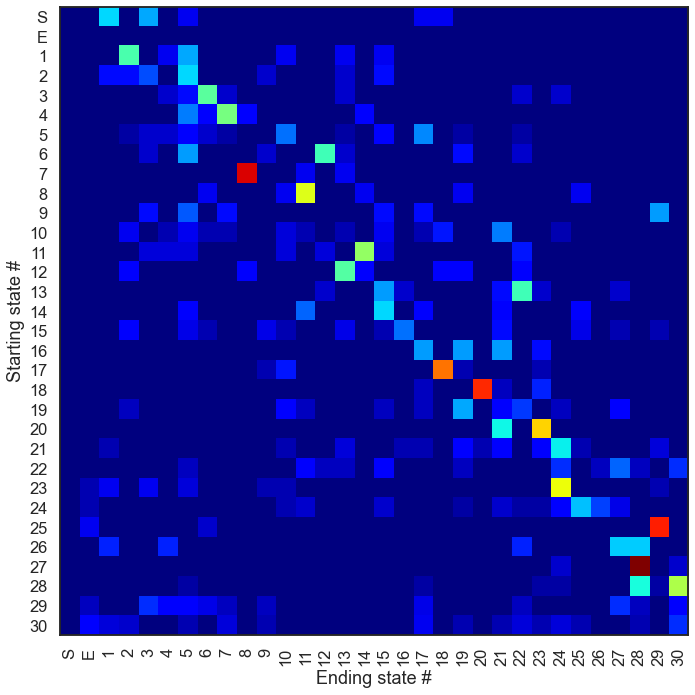

In [72]:
f, ax = plt.subplots(1,1,figsize = (10,10))
ax.imshow(trans_stev_mat2,interpolation='none',cmap='jet',aspect='auto')
ax.set_ylabel('Starting state #')
ax.set_xlabel('Ending state #')
ax.set_yticks(np.arange(len(slabs_stev)))
ax.set_yticklabels(slabs_stev)
ax.set_xticks(np.arange(len(slabs_stev)))
ax.set_xticklabels(slabs_stev,rotation = 90)
f.tight_layout()
fn="figs/recall_scenenum_trans_mat.pdf"
#plt.savefig(fn, transparent=True)

In [73]:
nonz=np.nansum(trans_ev_mat,axis=0)+np.nansum(trans_ev_mat,axis=1) #add rows/columns
qq=np.where(nonz!=0)[0] #find where non-zero

slabs_ev,trans_mat2,node_ev_szs2,ev_lab,j=[],np.zeros((len(qq),len(qq))),np.zeros((len(qq))),np.zeros(len(qq)),0
for i in range(sc_s):
    if any(x == i for x in qq):
        trans_mat2[:len(qq),j]=trans_ev_mat[qq,i] #cut out zero/nan rows/columns 
        trans_mat2[j,:len(qq)]=trans_ev_mat[i,qq] #cut out zero/nan rows/columns 
        slabs_ev.append(str(i-2+1))
        node_ev_szs2[j]=node_ev_szs[i]
        ev_lab[j]=e_o[i-2,1]
        j+=1
slabs_ev[0]='Start     ' #re-assign start/end
slabs_ev[1]='     End'
print('event labels of surviving events:',slabs_ev)                                                                         
print('storyline labels of surviving events:',ev_lab)

memo_trans=np.zeros((n_ev,n_ev))
for i in range(n_ev):
    memo_trans[i,:]=trans_ev_mat[i+2,2:] 
    memo_trans[i,i]=0

event labels of surviving events: ['Start     ', '     End', '1', '3', '4', '5', '6', '7', '8', '9', '10', '12', '13', '14', '15', '16', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '39', '40', '41', '42', '43', '44', '45', '47', '48', '49', '50', '51', '52']
storyline labels of surviving events: [1. 4. 2. 2. 4. 4. 0. 0. 1. 3. 2. 4. 0. 0. 2. 2. 0. 3. 2. 0. 4. 4. 2. 0.
 0. 1. 2. 2. 3. 3. 4. 2. 3. 3. 2. 4. 3. 3. 1. 3. 2. 2. 3. 1. 1. 3. 2. 1.
 4.]


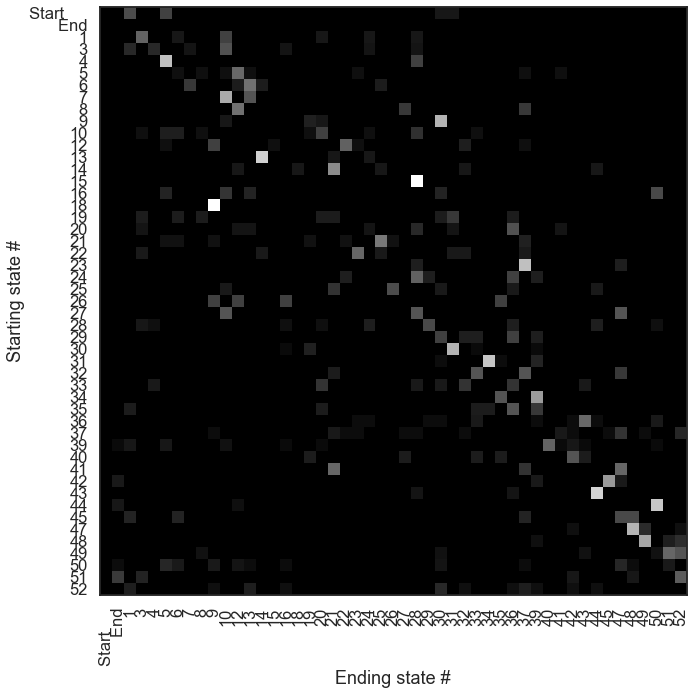

In [74]:
f, ax = plt.subplots(1,1,figsize = (10,10))
ax.imshow(trans_mat2,interpolation='none',cmap='gray',aspect='auto')
ax.set_ylabel('Starting state #')
ax.set_xlabel('Ending state #')
ax.set_yticks(np.arange(len(slabs_ev)))
ax.set_yticklabels(slabs_ev)
ax.set_xticks(np.arange(len(slabs_ev)))
ax.set_xticklabels(slabs_ev,rotation = 90)
f.tight_layout()
fn="figs/recall_scene_trans_mat.pdf"
plt.savefig(fn, transparent=True)

memo thresh: 0.0


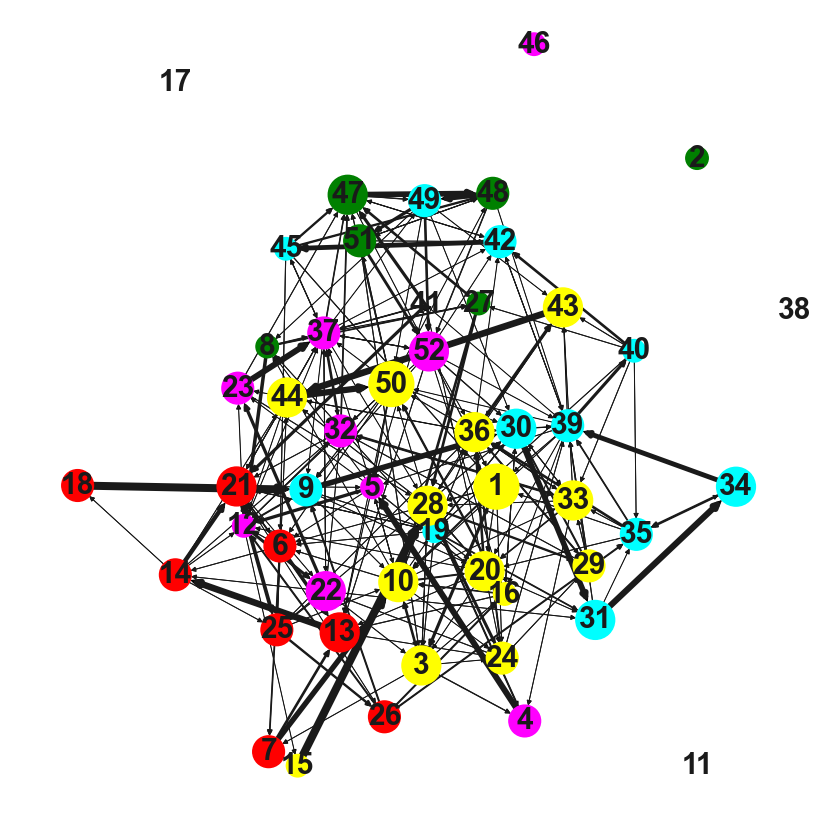

In [75]:
perc_thr=80
blah2=cdat_a_m[np.where(np.isnan(memo_trans)==0)]
memothr=np.percentile(blah2,perc_thr) #2 
print('memo thresh:',memothr)
no_mult,ed_mult=50000,8
G_memo,ew_memo,cmap_memo=create_network(memo_trans,memothr,e_o)
network_plot(G_memo,ew_memo,node_szs,ed_mult,"memo_trans_graph",30)

In [76]:
# create state space and initial state probabilities
pi = np.zeros((len(slabs)))
pi[0]=1 #start in start state
state_space = pd.Series(pi, index=slabs, name='states')
#print('init state space:\n%s' %state_space)
q_df = pd.DataFrame(columns=slabs, index=slabs)
for i in range(len(slabs)):
    q_df.loc[slabs[i]]=trans_mat[i,:] # create transition matrix
q=q_df.values
edges_wts = _get_markov_edges(q_df)

#re-do for ev states
pi_stev = np.zeros((len(slabs_stev)))
pi_stev[0]=1 #start in start state
state_space_stev = pd.Series(pi_stev, index=slabs_stev, name='states_stev')
q_df_stev = pd.DataFrame(columns=slabs_stev, index=slabs_stev)
for i in range(len(slabs_stev)):
    q_df_stev.loc[slabs_stev[i]]=trans_stev_mat2[i,:] # create transition matrix
q_stev=q_df_stev.values
edges_wts_stev = _get_markov_edges(q_df_stev)

#re-do for ev states
pi_ev = np.zeros((len(slabs_ev)))
pi_ev[0]=1 #start in start state
state_space_ev = pd.Series(pi_ev, index=slabs_ev, name='states_ev')
q_df_ev = pd.DataFrame(columns=slabs_ev, index=slabs_ev)
for i in range(len(slabs_ev)):
    q_df_ev.loc[slabs_ev[i]]=trans_mat2[i,:] # create transition matrix
q_ev=q_df_ev.values
edges_wts_ev = _get_markov_edges(q_df_ev)

32


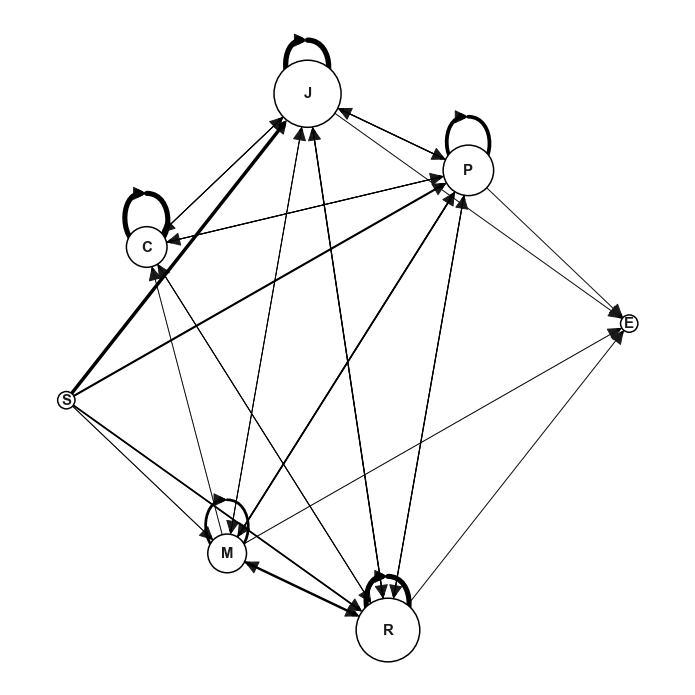

In [77]:
G=nx.MultiDiGraph() # create graph object
G.add_nodes_from(slabs) # nodes correspond to states
# edges represent transition probabilities
for k, v in edges_wts.items():
    tmp_origin, tmp_destination = k[0], k[1]
    if v>0:
        G.add_edge(tmp_origin,tmp_destination,weight=v,label=v,color='black')
edge_weights0={(n1,n2):d['weight'] for n1,n2,d in G.edges(data=True)}
edge_weights=list(edge_weights0.values())
print(len(edge_weights))
f, ax = plt.subplots(1,1,figsize = (10,10))
pos = nx.drawing.nx_pydot.graphviz_layout(G, prog='neato')
ser_x=[1,8,2,3,4,5,6,7] #override
ser_y=[4,5,6,2,8,1,7,3]
for i in range(len(slabs)):
    pos[slabs[i]]=(ser_x[i]*10,ser_y[i]*10)
nx.draw_networkx(G, pos,arrowsize=30,node_color='white',
                 font_size=15,edgecolors='black',node_size=node_szs_trans*15000,font_weight='bold')
# create edge labels for jupyter plot but is not necessary
edge_labels = {(n1,n2):d['label'] for n1,n2,d in G.edges(data=True)}
#nx.draw_networkx_edge_labels(G , pos, edge_labels=edge_labels,label_pos=0.4,font_size=15)
edges=nx.draw_networkx_edges(G,pos,node_size=node_szs_trans*15000,width=2,edge_color='black')
M = G.number_of_edges()
for i in range(M):
    edges[i].set_linewidth(edge_weights[i]*8)
#plt.show()
f.tight_layout()
fn="figs/recall_em_trans_graph.pdf"
sps=['top','bottom','left','right']
for i in range(len(sps)):
    ax.spines[sps[i]].set_visible(False)
plt.savefig(fn, transparent=True)

32


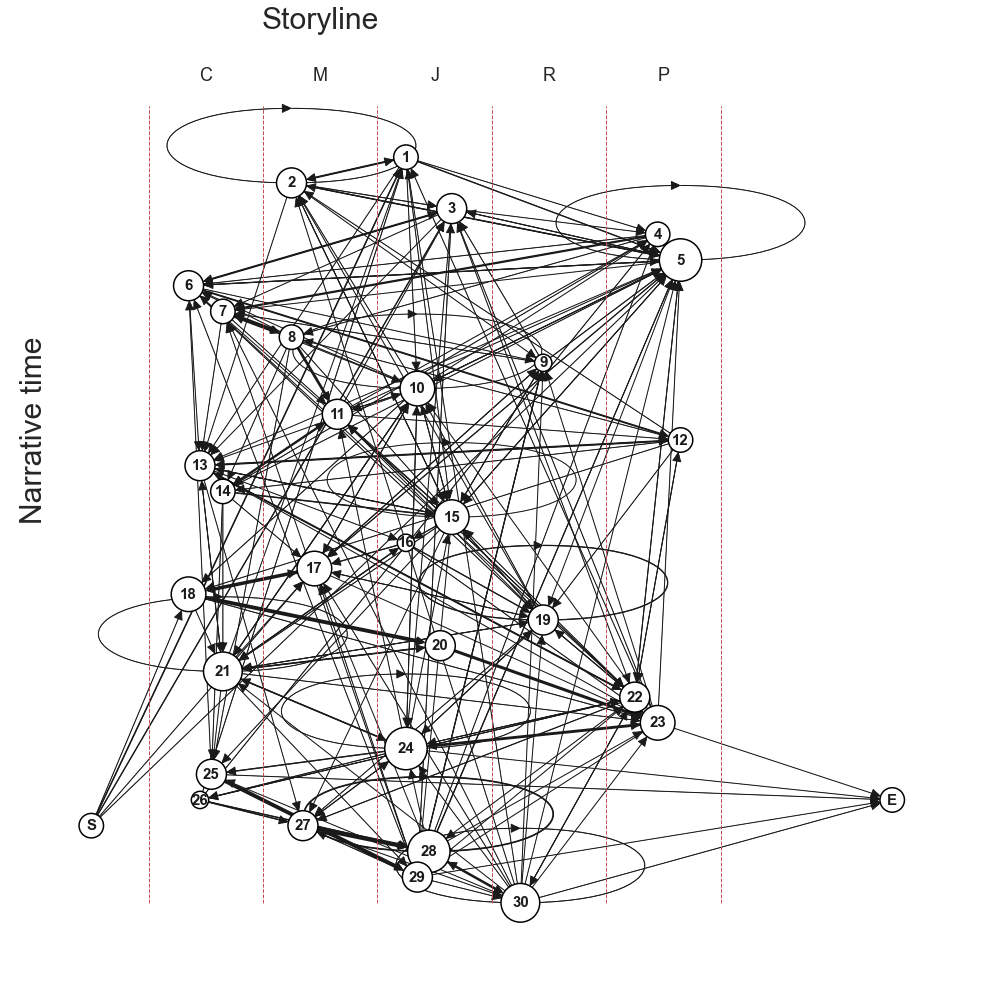

In [78]:
G_stev=nx.MultiDiGraph() # create graph object
G_stev.add_nodes_from(slabs_stev) # nodes correspond to states
# edges represent transition probabilities
for k, v in edges_wts_stev.items():
    tmp_origin, tmp_destination = k[0], k[1]
    if v>0:
        G_stev.add_edge(tmp_origin,tmp_destination,weight=v,label=v,color='black')
edge_weights_stev0={(n1,n2):d['weight'] for n1,n2,d in G_stev.edges(data=True)}
edge_weights_stev=list(edge_weights_stev0.values())
print(len(edge_weights))

#create new node_szs!!!
f, ax = plt.subplots(1,1,figsize = (14,14))
pos[slabs_ev[0]]=(10,len(slabs_stev)*10)
pos[slabs_ev[1]]=(80,10)
for i in range(2,len(slabs_stev)):
    pos[slabs_stev[i]]=(int(stev_l[i]+2)*10+np.random.permutation(5)[0]-2.5,(len(slabs_stev)-i)*10)
nx.draw_networkx(G_stev,pos,arrowsize=20,node_color='white',
                 font_size=15,edgecolors='black',node_size=node_stev_szs2*30000,font_weight='bold')
# create edge labels for jupyter plot but is not necessary
edge_labels = {(n1,n2):d['label'] for n1,n2,d in G_stev.edges(data=True)}
edges=nx.draw_networkx_edges(G_stev,pos,width=2,node_size=node_stev_szs2*30000,edge_color='k')
M = G_stev.number_of_edges()
for i in range(M):
    edges[i].set_linewidth(edge_weights_stev[i]*5)
for i in range(1,len(slabs)):
    plt.plot([i*10+5,i*10+5],[10,len(slabs_stev)*10],'--r',linewidth=1)
    if i<len(slabs)-1:
        plt.text(i*10+10,len(slabs_stev)*10+10,slabs[i+1], horizontalalignment='center')
plt.text(len(slabs)//2*10,len(slabs_stev)*10+30,'Storyline', horizontalalignment='center',fontsize=30)
sps=['top','bottom','left','right']
for i in range(len(sps)):
    ax.spines[sps[i]].set_visible(False)
plt.text(5,len(slabs_stev)//2*10,'Narrative time',rotation=90,horizontalalignment='center',fontsize=30)
f.tight_layout()
fn="figs/recall_stscene_trans_graph.pdf"
plt.savefig(fn, transparent=True)

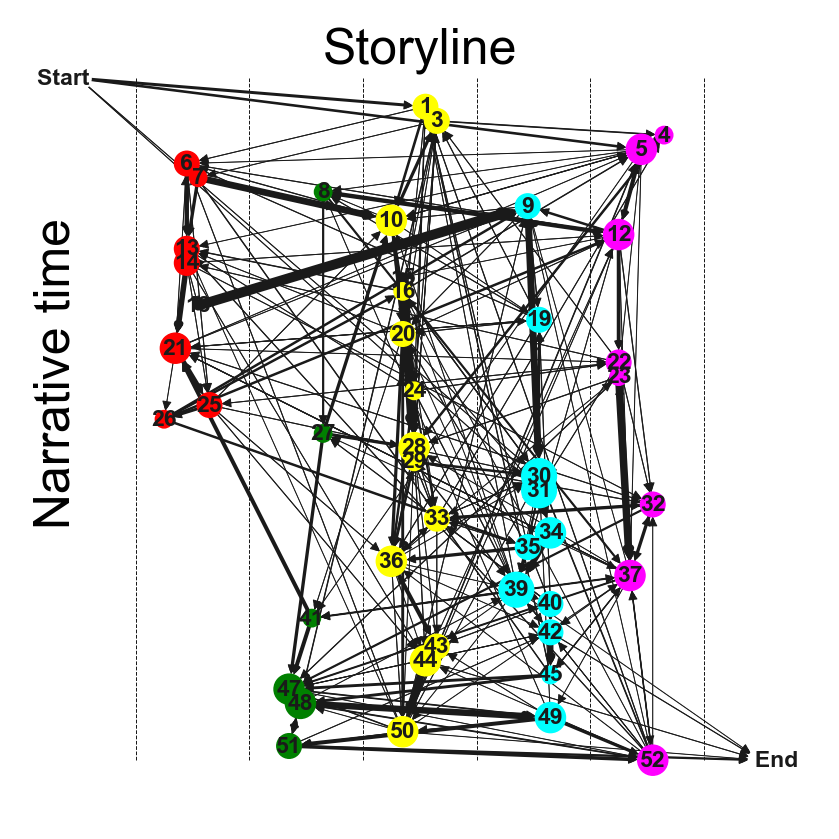

In [79]:
#set up new color scheme, including two black events 
#find events that have 0 transitions and remove for this plot
curr_fos=50
new_cols=['white','white']
buff=new_cols+cmap_caus
nonz=np.nansum(trans_ev_mat,axis=0)+np.nansum(trans_ev_mat,axis=1) #add rows/columns
qq=np.where(nonz!=0)[0] #find where non-zero
qq=qq.astype(int)
cmap_caus_g_ev=[""] * len(qq)
for i in range(len(qq)):
    cmap_caus_g_ev[i]=buff[qq[i]]

#repeat for ev_states
G_ev=nx.MultiDiGraph() # create graph object
G_ev.add_nodes_from(slabs_ev) # nodes correspond to states
# edges represent transition probabilities
for k, v in edges_wts_ev.items():
    tmp_origin, tmp_destination = k[0], k[1]
    if v>0:
        G_ev.add_edge(tmp_origin,tmp_destination,weight=v,label=v,color='black')
edge_weights0={(n1,n2):d['weight'] for n1,n2,d in G_ev.edges(data=True)}
edge_weights_ev=list(edge_weights0.values())

#create new node_szs!!!
f, ax = plt.subplots(1,1,figsize = (12,12))
#pos=nx.drawing.nx_pydot.graphviz_layout(G_ev,prog='neato',root='None') #w/ proximity automatically created 
pos[slabs_ev[0]]=(10,len(slabs_ev)*10)
pos[slabs_ev[1]]=(70,10)
for i in range(2,len(slabs_ev)):
    pos[slabs_ev[i]]=(int(ev_lab[i]+2)*10+np.random.permutation(5)[0]-2.5,(len(slabs_ev)-i)*10)
nx.draw_networkx(G_ev,pos,arrowsize=20,node_color=cmap_caus_g_ev,#edgecolors='white',node_color='white',
                 font_size=23,node_size=node_ev_szs2*30000,font_weight='bold')
# create edge labels for jupyter plot but is not necessary
edge_labels = {(n1,n2):d['label'] for n1,n2,d in G_ev.edges(data=True)}
#nx.draw_networkx_edge_labels(G_ev, pos, edge_labels=edge_labels,label_pos=0.4,font_size=15)
edges=nx.draw_networkx_edges(G_ev,pos,node_size=node_ev_szs2*30000,width=2,edge_color='k') 
M = G_ev.number_of_edges()
for i in range(M):
    edges[i].set_linewidth(edge_weights_ev[i]*10) #5
for i in range(1,len(slabs)):
    plt.plot([i*10+5,i*10+5],[10,len(slabs_ev)*10],'--k',linewidth=1) #separation lines
    #if i<len(slabs)-1:
    #    plt.text(i*10+10,len(slabs_ev)*10+10,slabs[i+1], horizontalalignment='center',fontsize=25) #storyline labels
plt.text(40,len(slabs_ev)*10+10,'Storyline', horizontalalignment='center',fontsize=curr_fos,color='black')
sps=['top','bottom','left','right']
for i in range(len(sps)):
    ax.spines[sps[i]].set_visible(False)
plt.text(8,180,'Narrative time',rotation=90,horizontalalignment='center',fontsize=curr_fos,color='black')
f.tight_layout()
fn="figs/recall_scene_trans_graph.pdf"
plt.savefig(fn, transparent=True)

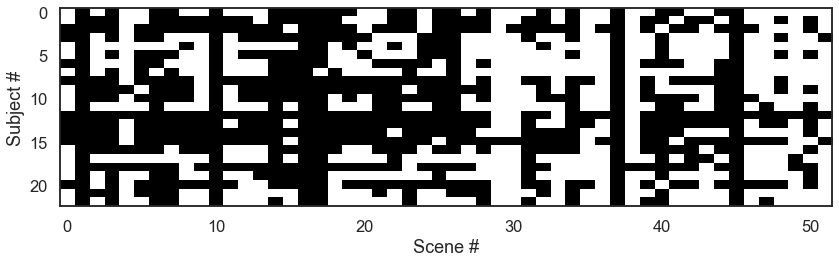

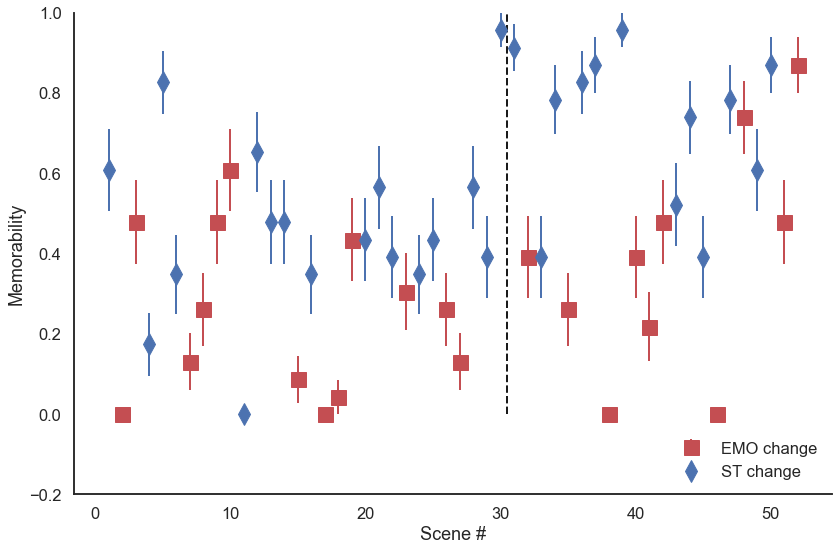

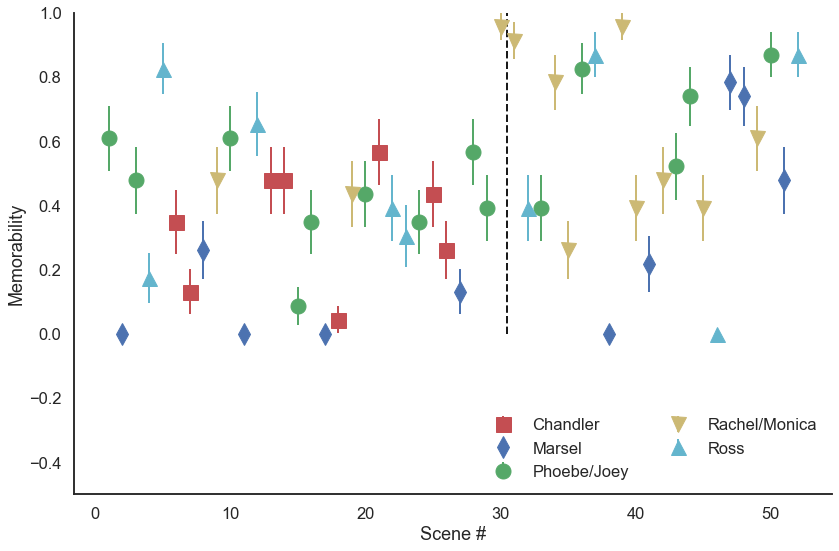

In [80]:
# plot x-sub memorability
f, ax = plt.subplots(1,1,figsize = (12,4))
ax.imshow(memo,interpolation='none',cmap='gray',aspect='auto')
ax.set_xlabel('Scene #')
ax.set_ylabel('Subject #')
fn='figs/recall_xsub_memorability.pdf'
f.tight_layout()
f.savefig(fn, transparent=True)

#split up by st vs. emo
f, ax = plt.subplots(1,1,figsize = (12,8))
x,y,err=np.linspace(1,n_ev,n_ev),np.mean(memo,axis=0),np.std(memo,axis=0)/np.sqrt(nSubs)
x=x.astype(int)
#ax.errorbar(x,y,err,linestyle='--',color='k')
for i in range(2):
    x2=np.where(df['STchange_post'][:-1]==i)[0]
    x2=x2.astype(int)
    y2=y[x2]
    err2=err[x2]
    mn,cn='s','r'
    if i==1:
        mn,cn='d','b'
    ax.errorbar(x2+1,y2,err2,color=cn,marker=mn,markersize=15,linestyle='none')
ax.set_ylim([-0.2,1])
ax.legend(['EMO change','ST change'],loc='lower right',frameon=False)
ax.vlines(x=e2s+0.5,ymin=0,ymax=1,color='k',linestyle='--')
ax.set_xlabel('Scene #')
ax.set_ylabel('Memorability')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
f.tight_layout()
fn='figs/recall_xsub_memorability_transtype.pdf'
f.savefig(fn, transparent=True)

#### split up by storyline
f, ax = plt.subplots(1,1,figsize = (12,8))
for i in range(len(ems)):
    x2=np.where(df['storylineNum'][:-1]==i)[0]
    x2=x2.astype(int)
    y2=y[x2]
    err2=err[x2]
    mn,cn='s','r'
    if i==1:
        mn,cn='d','b'
    elif i==2:
        mn,cn='o','g'
    elif i==3:
        mn,cn='v','y'
    elif i==4:
        mn,cn='^','c'
    elif i==5:
        mn,cn='p','m'
    ax.errorbar(x2+1,y2,err2,color=cn,marker=mn,markersize=15,linestyle='none')
ax.set_ylim([-0.5,1])
ax.legend(ems,loc='lower right',ncol=2,frameon=False)
ax.vlines(x=e2s+0.5,ymin=0,ymax=1,color='k',linestyle='--')
ax.set_xlabel('Scene #')
ax.set_ylabel('Memorability')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
f.tight_layout()
fn='figs/recall_xsub_memorability_em.pdf'
f.savefig(fn, transparent=True)

Text(0.5, 1.0, 'p value: 0.000')

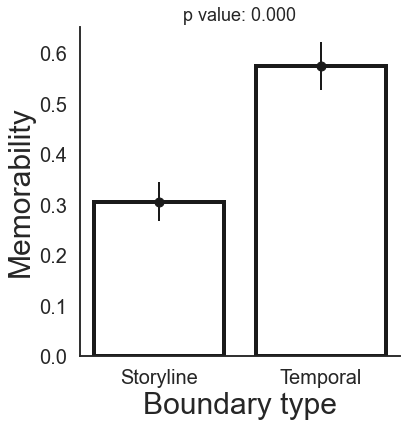

In [81]:
#find mean of ST and EMO
st_emo_mean=np.zeros((nSubs,2))
for i in range(2):
    qq=np.where(df['STchange_post'][:-1]==i)[0]
    st_emo_mean[:,i]=np.mean(memo[:,qq],axis=1) #average over st scenes
f, ax = plt.subplots(1,1,figsize = (6,6))
x,y,err=[0,1],np.mean(st_emo_mean,axis=0),np.std(st_emo_mean,axis=0)/np.sqrt(nSubs)
ax.bar(x,y,color='w',edgecolor='k',linewidth=4)
ax.errorbar(x,y,err,color='k',linestyle='none',marker='o')
ax.set_xlabel('Boundary type',fontsize=fos)
ax.set_ylabel('Memorability',fontsize=fos)
ax.set_xticks(np.arange(2))
ax.set_xticklabels(['Storyline','Temporal'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)    
ax.tick_params(axis='both', which='major',labelsize=fos*2/3)
f.tight_layout()
fn='figs/recall_memorability_transtype.pdf'
f.savefig(fn, transparent=True)
tval,pval=ttest_rel(st_emo_mean[:,0],st_emo_mean[:,1])
ax.set_title('p value: %.3f' %pval)

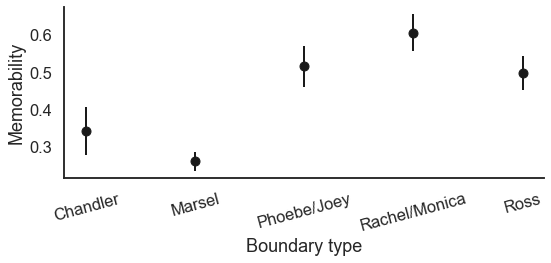

In [82]:
#find mean of each storyline
em_mean=np.zeros((nSubs,len(ems)))
for i in range(len(ems)):
    qq=np.where(df['storylineNum'][:-1]==i)[0]
    em_mean[:,i]=np.mean(memo[:,qq],axis=1) #average over st scenes
f, ax = plt.subplots(1,1,figsize = (8,4))
x,y,err=np.linspace(0,len(ems)-1,len(ems)),np.mean(em_mean,axis=0),np.std(em_mean,axis=0)/np.sqrt(nSubs)
ax.errorbar(x,y,err,linestyle='none',color='k',marker='o')
ax.set_xlabel('Boundary type')
ax.set_ylabel('Memorability')
ax.set_xticks(np.arange(len(ems)))
ax.set_xticklabels(ems,rotation=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)    
f.tight_layout()
fn='figs/recall_memorability_em.pdf'
f.savefig(fn, transparent=True)

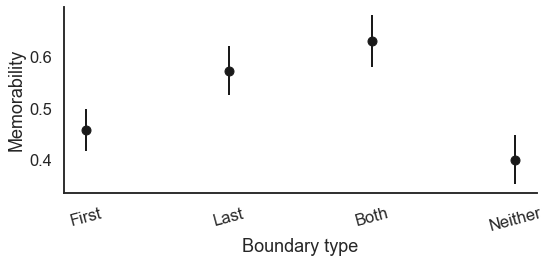

In [83]:
#find mean based on whether scene was first, last, both, or neither
flbn_mean=np.zeros((nSubs,4))
flbnl=['First','Last','Both','Neither']
qq=np.where(df['FirstScene'][:-1]==1)[0]
flbn_mean[:,0]=np.mean(memo[:,qq],axis=1)
qq=np.where(df['LastScene'][:-1]==1)[0]
flbn_mean[:,1]=np.mean(memo[:,qq],axis=1)
qq=np.where(np.logical_and(df['FirstScene'][:-1]==1,df['LastScene'][:-1]==1))[0]
flbn_mean[:,2]=np.mean(memo[:,qq],axis=1)
qq=np.where(np.logical_and(df['FirstScene'][:-1]==0,df['LastScene'][:-1]==0))[0]
flbn_mean[:,3]=np.mean(memo[:,qq],axis=1)

f, ax = plt.subplots(1,1,figsize = (8,4))
x,y,err=np.linspace(0,4-1,4),np.mean(flbn_mean,axis=0),np.std(flbn_mean,axis=0)/np.sqrt(nSubs)
ax.errorbar(x,y,err,linestyle='none',color='k',marker='o')
ax.set_xlabel('Boundary type')
ax.set_ylabel('Memorability')
ax.set_xticks(np.arange(len(flbnl)))
ax.set_xticklabels(flbnl,rotation=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)    
f.tight_layout()
fn='figs/recall_memorability_order.pdf'
f.savefig(fn, transparent=True)            

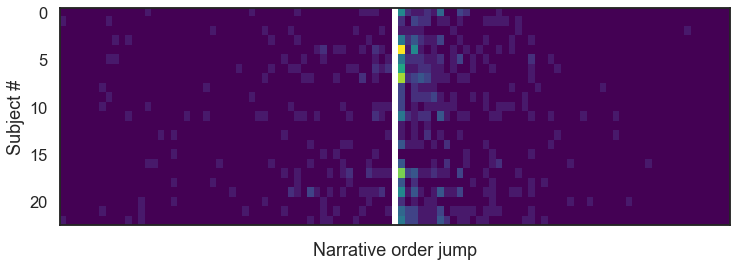

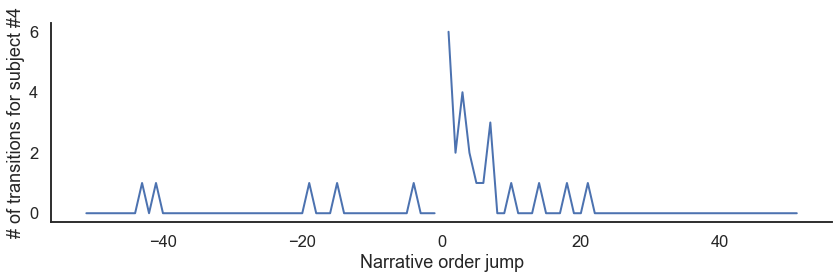

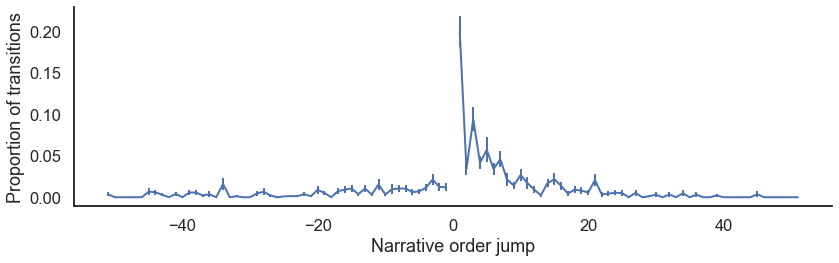

In [84]:
# plot across-subject histograms for narrative order
f, ax = plt.subplots(1,1,figsize = (12,4))
ax.imshow(xs_jumps,interpolation='none',cmap='viridis',aspect='auto')
ax.set_xlabel('Narrative order jump')
ax.set_ylabel('Subject #')
ax.set_xticks(np.arange(0,maxj*2+1,step=5))
ax.set_xticklabels(js[0:5:-1])
plt.xticks(rotation=90)
plt.show()
f.tight_layout()
fn='figs/recall_narr_jumps_all_sub.pdf'
f.savefig(fn, transparent=True)

f, ax = plt.subplots(1,1,figsize = (12,4))
ax.plot(js[:-1],xs_jumps[3,:])
ax.set_xlabel('Narrative order jump')
ax.set_ylabel('# of transitions for subject #4')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
f.tight_layout()
fn='figs/recall_narr_jumps_sampsub_narr_jumps.pdf'
f.savefig(fn, transparent=True)

xs_jumps_p=np.zeros((xs_jumps.shape)) #as proportion
for i in range(len(subs)):
    xs_jumps_p[i,:]=np.divide(xs_jumps[i,:],np.nansum(xs_jumps[i,:]))
f, ax = plt.subplots(1,1,figsize = (12,4))
ax.errorbar(js[:-1],np.mean(xs_jumps_p,axis=0),np.std(xs_jumps_p,axis=0)/np.sqrt(len(subs)))
ax.set_xlabel('Narrative order jump')
ax.set_ylabel('Proportion of transitions')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
f.tight_layout()
fn='figs/recall_narr_jumps_xsub_narr_jumps.pdf'
f.savefig(fn, transparent=True)

# Transition-wise strategy analysis

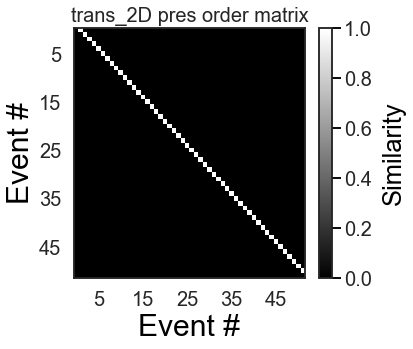

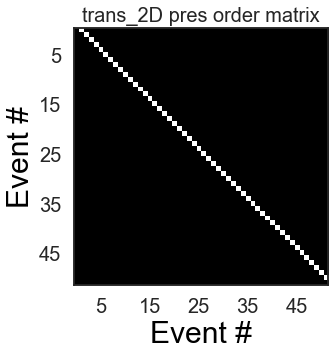

In [85]:
#first create pres order matrices - Fig 3A
pres_order_m=np.zeros((n_ev,n_ev))
for i in range(n_ev): #nSubs #loop over subs
    if i<n_ev-1:
        pres_order_m[i,i+1]=1

for i in range(n_ev): #add nans after plot to avoid viz issues
    pres_order_m[i,i]=0
    
plot_trans_mat(pres_order_m,'trans_2D pres order matrix',0)

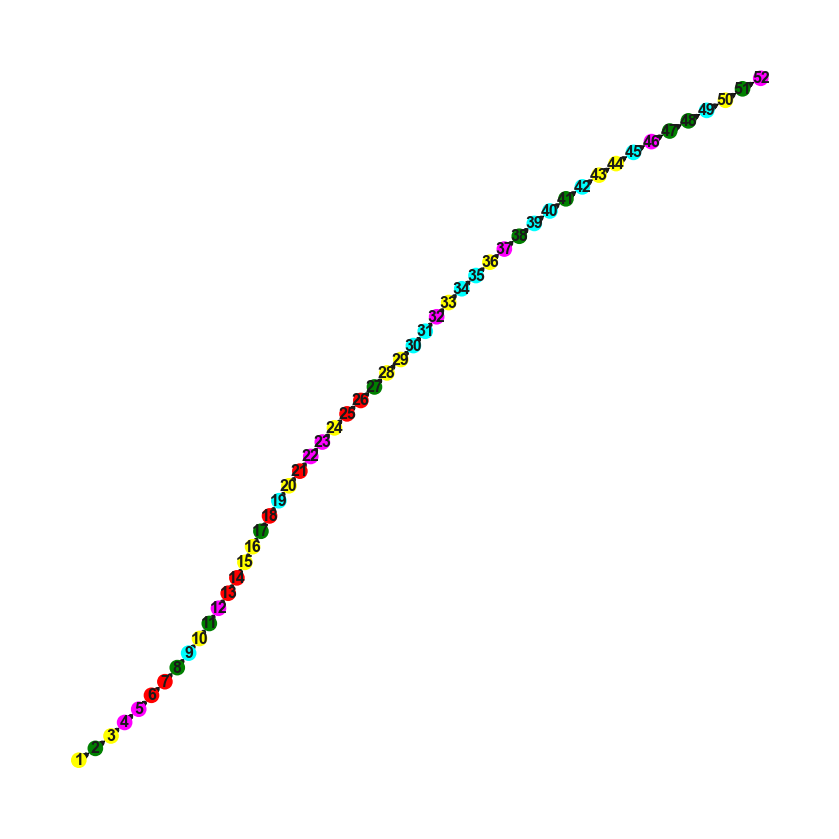

In [86]:
#plot pres order transition matrix (silly but illustrative)
blah2=cdat_a_m[np.where(np.isnan(pres_order_m)==0)]
presthr=np.percentile(blah2,perc_thr) #2 #minimum causality rating to keep'
no_mult,ed_mult=30000,5 #50000,8
node_szs=np.zeros((n_ev))+1/150
G_pres,ew_pres,cmap_pres=create_network(pres_order_m,presthr,e_o)
network_plot(G_pres,ew_pres,node_szs,ed_mult,"pres_trans_graph",16)

In [87]:
#setup variables and loop over transitions
preds=['Presented','Character','Place','Semantic','Top semantic','Causal','Top causal']#,'RSA-ag','Top RSA-ag']
tkl=['Pres','Char','Place','Sem','TSem','Caus','TCaus']#,'RSA-ag','TRSAag']
if ld_ang:
    preds=['Presented','Character','Place','Semantic','Top semantic','Causal','Top causal','RSA-ag','Top RSA-ag']
    tkl=['Pres','Char','Place','Sem','TSem','Caus','TCaus','RSA-ag','TRSAag']
n_pred=len(preds)-2 # #predictors
n_predp=len(preds)
chance_line=1/(n_ev-1) #can't go to itself
evs_a,evs_cumu_a=[None]*nSubs,np.zeros((nSubs,n_predp))
nStates=np.zeros((nSubs))
memo_trans_sub=np.zeros((n_ev,n_ev,nSubs))
for i in range(nSubs): #loop over subs
    diff=np.diff(states_a[i]) #find differences
    qq=np.where(diff!=0)[0]
    qq=np.hstack([0,qq+1]) #re-grab first state and then where there are diffs
    states=states_a[i].to_numpy() #convert series to np so we can index
    states=states[qq].astype(int)
    nStates[i]=len(states) # number of states for this subject
    cumu_ev=np.zeros((n_predp))
    
    if ld_ang:
        neur_mat=exmat_a[:,:,i]
    
        tneur_mat=np.zeros((n_ev,n_ev))
        for ii in range(n_ev):
            qq=np.where(neur_mat[ii,:]==np.max(neur_mat[ii,:]))[0]
            if np.max(neur_mat[ii,:])>0: #only assign if this isn't completely blank
                tneur_mat[ii,qq[0]]=1

        #plot_trans_mat(tneur_mat,'2D top neural transition matrix',1)

    #state-based analysis
    #presented order: next state is always presented order strategy
    #semantic: sem_2d_fs = 2-D semantic matrix
    #semantic top: tsem_2d_fs = 2-D semantic matrix w/ only top match for a scene
    #causality: cdat_a_m = 2-D causality matrix
    #causality top match: tcdat_a_m = 2-D matrix w/ only top match for a cause
    #neural similarity match: 2-D matrix with neural similarity from ang
    evs=np.zeros((int(nStates[i])-1))
    for ii in range(int(nStates[i])-1):
        pres_ev,caus_ev=0,0
        curr_state=states[ii]
        next_state=states[ii+1]
        memo_trans_sub[curr_state-1,next_state-1,i]=1
        #presented order evidence
        if next_state-curr_state==1:
            pres_ev=1

        #causal evidence - remember to 0 code
        #use curr_state for row and next state for column
        if np.nansum(cdat_a_m[curr_state-1,:])==0:
            char_ev,place_ev,sem_ev,tsem_ev,caus_ev,tcaus_ev,neur_ev,tneur_ev=0,0,0,0,0,0,0,0
        else:
            char_ev=char_trans[curr_state-1,next_state-1]/np.nansum(char_trans[curr_state-1,:])
            if np.nansum(place_trans[curr_state-1,:])>0:
                place_ev=place_trans[curr_state-1,next_state-1]/np.nansum(place_trans[curr_state-1,:])
            else:
                place_ev=0
            sem_ev=sem_2d_fs[curr_state-1,next_state-1]/np.nansum(sem_2d_fs[curr_state-1,:])
            tsem_ev=tsem_2d_fs[curr_state-1,next_state-1]/np.nansum(tsem_2d_fs[curr_state-1,:])
            caus_ev=cdat_a_m[curr_state-1,next_state-1]/np.nansum(cdat_a_m[curr_state-1,:])
            tcaus_ev=tcdat_a_m[curr_state-1,next_state-1]/np.nansum(tcdat_a_m[curr_state-1,:])
            if ld_ang:
                neur_ev=neur_mat[curr_state-1,next_state-1]/np.nansum(neur_mat[curr_state-1,:])
                tneur_ev=tneur_mat[curr_state-1,next_state-1]/np.nansum(tneur_mat[curr_state-1,:])
        ev_comb=[pres_ev,char_ev,place_ev,sem_ev,tsem_ev,caus_ev,chance_line]
        temp=np.where(ev_comb==np.max(ev_comb))[0]
        evs[ii]=temp[0]
        #ev_comb2=[pres_ev,char_ev,place_ev,sem_ev,tsem_ev,caus_ev,tcaus_ev,neur_ev,tneur_ev,chance_line]
        ev_comb2=[pres_ev,char_ev,place_ev,sem_ev,tsem_ev,caus_ev,tcaus_ev,chance_line]
        cumu_ev[:n_predp]=cumu_ev[:n_predp]+ev_comb2[:n_predp] #cumulative evidence
    evs_a[i]=evs #best matches - may not add to 1 sometimes all below chance
    evs_cumu_a[i,:]=cumu_ev/(nStates[i]-1)#/np.sum(cumu_ev) #norm relative to # transitions

memo_m x causal: 0.5330391328071806, 2.1840399844670302e-198
memo_m x tcausal: 0.5310317130946071, 1.2274393275450325e-196
memo_m x rev causal: 0.010474596605524005, 0.5861372738410949
[[0.   0.   0.39 0.   0.   0.09 0.   0.   0.   0.26]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.16 0.   0.   0.16 0.   0.   0.08 0.   0.   0.32]
 [0.   0.   0.   0.   0.75 0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.06 0.   0.06 0.   0.06]
 [0.   0.   0.   0.   0.   0.   0.22 0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.67]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.09]
 [0.   0.   0.06 0.   0.12 0.12 0.   0.06 0.   0.  ]]


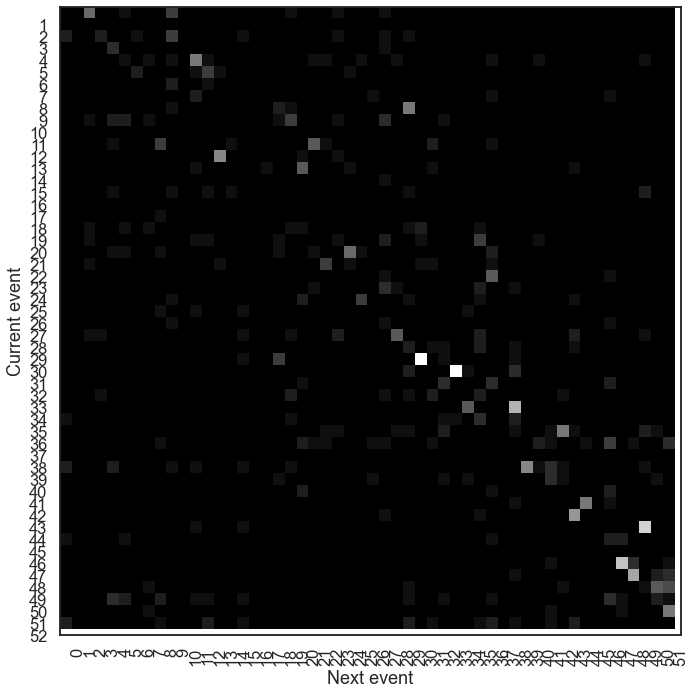

In [88]:
memo_trans_m=np.mean(memo_trans_sub,axis=2)
x,y=memo_trans_m.flatten(),cdat_a_m.flatten()
qq=np.where(np.logical_and(np.isnan(x)==0,np.isnan(y)==0))
rval,pval=pearsonr(x[qq],y[qq])
print('memo_m x causal: %s, %s' %(rval,pval))
y=tcdat_a_m.flatten()
qq=np.where(np.logical_and(np.isnan(x)==0,np.isnan(y)==0))
rval,pval=pearsonr(x[qq],y[qq])
print('memo_m x tcausal: %s, %s' %(rval,pval))
y=cdat_a_m.T.flatten()
qq=np.where(np.logical_and(np.isnan(x)==0,np.isnan(y)==0))
rval,pval=pearsonr(x[qq],y[qq])
print('memo_m x rev causal: %s, %s' %(rval,pval))

sn='pydata/memo_trans_sub.npy'
np.save(sn,memo_trans_sub)

f, ax = plt.subplots(1,1,figsize = (10,10))
ax.imshow(memo_trans_m,interpolation='none',cmap='gray',aspect='auto')
ax.set_ylabel('Current event')
ax.set_xlabel('Next event')
ax.set_yticks(np.arange(1,n_ev+1))
ax.set_xticks(np.arange(1,n_ev+1))
ax.set_xticklabels(np.arange(n_ev),rotation = 90)
f.tight_layout()
fn="figs/recall_scene_trans_mat.pdf"
plt.savefig(fn, transparent=True)
print(memo_trans[:10,:10])

memo thresh: 0.0


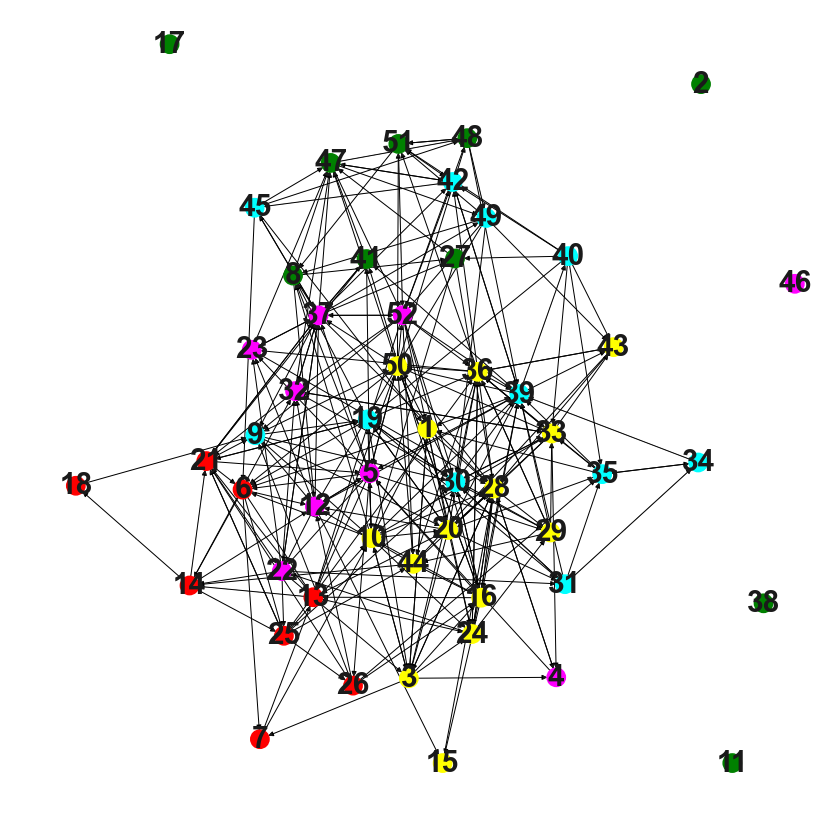

In [89]:
perc_thr=80
#causal
blah2=cdat_a_m[np.where(np.isnan(memo_trans_m)==0)]
memothr=np.percentile(blah2,perc_thr) #2 #minimum causality rating to keep'
print('memo thresh:',memothr)
no_mult,ed_mult=50000,0.5
G_memo,ew_memo,cmap_memo=create_network(memo_trans_m,memothr,e_o)
network_plot(G_memo,ew_memo,node_szs,ed_mult,"memo_transition_graph",30)

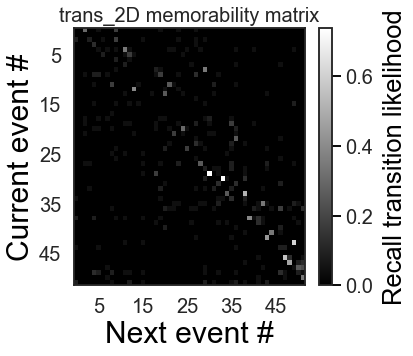

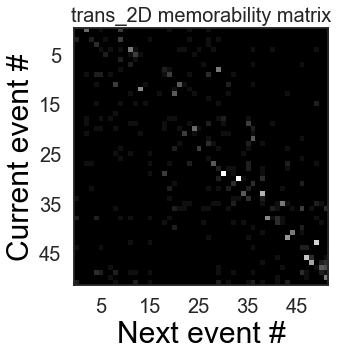

In [90]:
plot_trans_mat(memo_trans_m,'trans_2D memorability matrix',3)

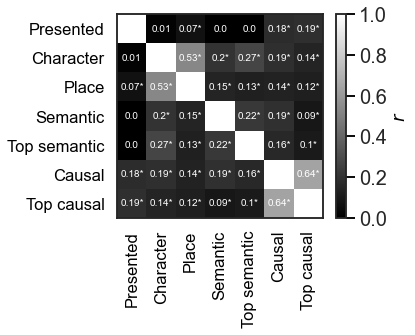

In [118]:
#create cross-correlation plot across transition strategies
comb_mat=np.zeros((n_ev,n_ev,n_predp))
comb_mat[:,:,0],comb_mat[:,:,1],comb_mat[:,:,2]=pres_order_m,char_trans,place_trans
comb_mat[:,:,3],comb_mat[:,:,4]=sem_2d_fs,tsem_2d_fs
comb_mat[:,:,5],comb_mat[:,:,6]=cdat_a_m,tcdat_a_m
if ld_ang:
    comb_mat[:,:,7],comb_mat[:,:,8]=neur_mat,tneur_mat
corr_mat=np.zeros((n_predp,n_predp,2))
for i in range(n_predp):
    for ii in range(n_predp):
        mat1=comb_mat[:,:,i].flatten()
        mat2=comb_mat[:,:,ii].flatten()
        qq=np.where(np.logical_and(~np.isnan(mat1),~np.isnan(mat2)))[0]
        rval,pval=pearsonr(mat1[qq],mat2[qq])
        corr_mat[i,ii,0],corr_mat[i,ii,1]=rval,pval

f, ax = plt.subplots(1,1, figsize = (fs1*2//3,fs2/2))
im=ax.imshow(corr_mat[:,:,0],interpolation='none',cmap=cm,aspect='auto',vmin=0, vmax=1)

for i in range(corr_mat.shape[0]):
    for j in range(corr_mat.shape[1]):
        if i!=j:
            q=np.round(corr_mat[i,j,0]*100)/100
            if corr_mat[i,j,1]<0.05:
                ax.text(j,i,f"{q}*",ha="center",va="center",color="white",fontsize=fos/3) #f"{num:.2f}"
            else:
                ax.text(j,i,f"{q}",ha="center",va="center",color="white",fontsize=fos/3) #f"{num:.2f}"

cbar=f.colorbar(im)
cbar.set_label('$\it{r}$', rotation=90,color='black')
cbar.ax.tick_params(labelsize=fos*2/3,color='black') 
tk=np.linspace(0,corr_mat.shape[0]-1,corr_mat.shape[0])
ax.set_xticks(tk)
#ax.set_xticklabels(tkl,rotation = 90,color='black')
ax.set_xticklabels(preds,rotation = 90,color='black')
ax.set_yticks(tk)
#ax.set_yticklabels(tkl,rotation = 0,color='black')
ax.set_yticklabels(preds,rotation = 0,color='black')
fn=figf+'pred_corr'+str(sem_meth)+'.pdf'
f.tight_layout()
plt.savefig(fn, transparent=True)

In [92]:
#calculate stickiness - likelihood of staying vs. changing strategy
perms=100
stay_perc=np.zeros((nSubs))
stay_perc_perm=np.zeros((nSubs,perms))
min_ev=12 #set min # of transitions to avoid large variance
for i in range(nSubs): #loop over subs
    evs=evs_a[i].astype(int)
    diff=np.diff(evs)
    if len(diff)>=min_ev:
        stay_perc[i]=len(np.where(diff==0)[0])/len(diff)
        for ii in range(perms):
            q0=np.random.permutation(len(evs))
            evs_scram=evs[q0]
            diff_perm=np.diff(evs_scram)
            stay_perc_perm[i,ii]=len(np.where(diff_perm==0)[0])/len(diff_perm)
    else:
        stay_perc[i]=math.nan
        
stay_perc_perm_m=np.mean(stay_perc_perm,axis=1)
qq=np.where(np.isnan(stay_perc)==0)[0]
stat,p=stats.ttest_1samp(stay_perc[qq]-stay_perc_perm_m[qq],popmean=0)
print('Stay proportion:',np.mean(stay_perc[qq]))
print('Stay proportion, perm:',np.mean(stay_perc_perm_m[qq]))
print('1-samp t-test stat: %s, p: %s, N: %s' %(stat,p,len(qq)))
ystr1,fn='Stay proportion','figs/stay_percentage.pdf'

Stay proportion: 0.1691258997925463
Stay proportion, perm: 0.18217967956429698
1-samp t-test stat: -0.7106542348897726, p: 0.48640538022162194, N: 19


In [93]:
#visualize strategy!
#sort by conditions to group together subjects for plot
mx_s=int(np.max(nStates)) #max # states
strat_mat,stratct=np.zeros((nSubs,mx_s)),np.zeros((nSubs,n_pred))
fir_pres_ord,sec_pres_ord=np.zeros((nSubs)),np.zeros((nSubs))
for i in range(nSubs): #loop over subs
    evs=evs_a[i].astype(int)+1 #add 1 to dissociate from 0 (no response)
    if len(evs)>1:
        halfpt=int(np.floor(len(evs)/2))
        strat_mat[i,:int(nStates[i]-1)]=evs
        fir_pres_ord[i]=len(np.where(evs[:halfpt]==1)[0])/halfpt
        sec_pres_ord[i]=len(np.where(evs[halfpt:]==1)[0])/(len(evs)-halfpt)
        for ii in range(n_pred): #loop over strategies
            stratct[i,ii]=len(np.where(evs==ii+1)[0])
        stratct[i,:]=stratct[i,:]/np.sum(stratct[i,:])
    else:
        fir_pres_ord[i]=math.nan
        sec_pres_ord[i]=math.nan
        stratct[i,:]=math.nan
        evs_cumu_a[i,:]=math.nan #add this to make nans where not >1 event

#export to R for ANOVAs
#put data into dataframe
sub_num=np.zeros((len(subs)))
for i in range(nSubs): #loop over all of the participants
    sub_num[i]=int(subs[i])

dft=pd.DataFrame()
dft['Sub']=sub_num+0
dft['PresEv']=evs_cumu_a[:,0]
dft['CharEv']=evs_cumu_a[:,1]
dft['PlaceEv']=evs_cumu_a[:,2]
dft['SemEv']=evs_cumu_a[:,3]
dft['TopSemEv']=evs_cumu_a[:,4]
dft['CausEv']=evs_cumu_a[:,5]
dft['TopCausEv']=evs_cumu_a[:,6]
exportR=0
fn='RStuff/transitions'+str(sem_meth)+'.csv' #just put in this folder
if exportR:
    dft.to_csv(fn)

1.0


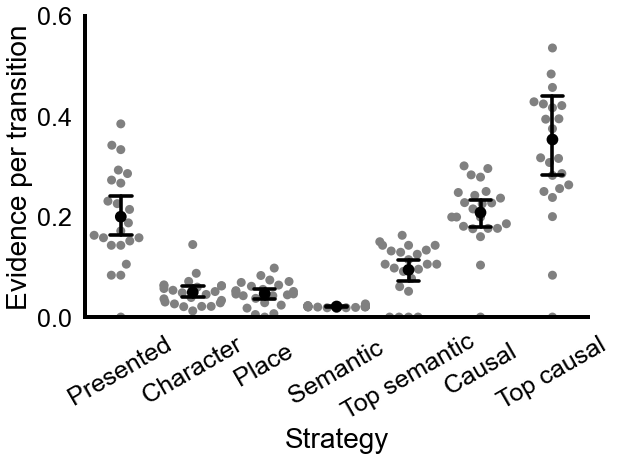

In [94]:
maxev=np.max(evs_cumu_a)
print(maxev)
ystr1,fn='Evidence per transition',figf + 'strategyCountMeanEvSwarm-'+str(sem_meth)+'.pdf'
barswarm(evs_cumu_a[:,0],evs_cumu_a[:,1],evs_cumu_a[:,2],evs_cumu_a[:,3],
         evs_cumu_a[:,4],evs_cumu_a[:,5],evs_cumu_a[:,6],ystr1,ystr1,fn,1) 

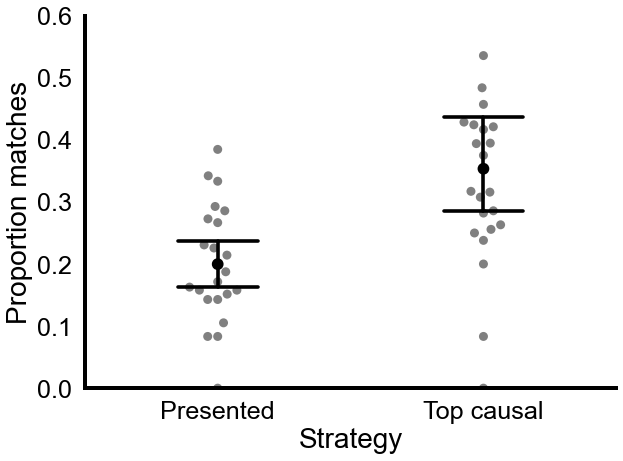

In [95]:
ystr1,fn='Proportion matches',figf + 'strategyCountMeanEvSwarm-'+str(sem_meth)+'_sel.pdf'
barswarm(evs_cumu_a[:,0],evs_cumu_a[:,6],[],[],[],[],[],ystr1,ystr1,fn,2) 

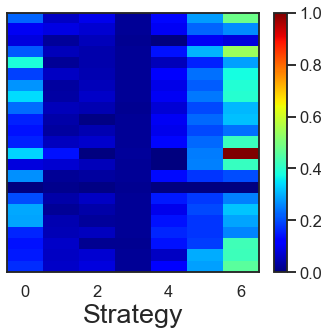

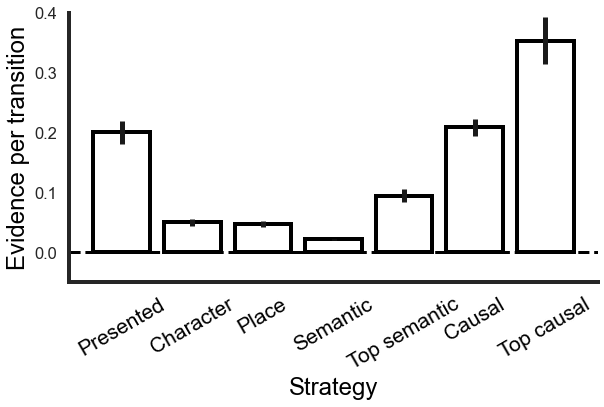

In [96]:
#plot strategy count for all strategies
lw=2
f, ax = plt.subplots(1,1, figsize = (5,5))
im=ax.imshow(evs_cumu_a,interpolation='none',cmap='jet',aspect='auto')
ax.set_xlabel('Strategy',fontsize=27)
ax.set_yticklabels([])
ax.tick_params(left = False)
cbar = f.colorbar(im)
f.tight_layout()

fn,yl=figf + 'strategyCountMeanEv-'+str(sem_meth)+'.pdf','Evidence per transition'
plot_strat(evs_cumu_a,preds,fn,yl,0,1)

In [97]:
tval,pval=ttest_rel(stratct[:,0],stratct[:,1])
print('t: %s, p: %s' %(tval,pval))

t: 4.093740012717498, p: 0.0004798686242599583


In [98]:
#stats, top causal v all
for i in range(n_predp-1):
    tval,pval=ttest_rel(evs_cumu_a[:,i],evs_cumu_a[:,6])
    print('ev, tcausal vs %s, t: %s, p: %s' %(preds[i],tval,pval))

ev, tcausal vs Presented, t: -4.343020306339027, p: 0.000261014828565207
ev, tcausal vs Character, t: -8.782757476397359, p: 1.211484427439534e-08
ev, tcausal vs Place, t: -7.7206680212964995, p: 1.059490187909506e-07
ev, tcausal vs Semantic, t: -8.53000924786547, p: 2.0024361456278077e-08
ev, tcausal vs Top semantic, t: -6.3144845237124, p: 2.3542787152236455e-06
ev, tcausal vs Causal, t: -4.632712471256719, p: 0.00012866022020185415


In [99]:
#save variables
sn='pydata/memo_subs.npy'
np.save(sn,subsn)
sn='pydata/memo.npy'
np.save(sn,memo)
sn='pydata/recall_l.npy'
np.save(sn,recall_l)
sn='pydata/sem_2d_fs.npy'
np.save(sn,sem_2d_fs)
sn='pydata/cdat_a_m.npy'
np.save(sn,cdat_a_m)
sn='pydata/char_trans.npy'
np.save(sn,char_trans)
sn='pydata/place_trans.npy'
np.save(sn,place_trans)
sn='pydata/tcdat_a_m.npy'
np.save(sn,tcdat_a_m)
sn='pydata/ticdat_a_m.npy'
np.save(sn,ticdat_a_m)
sn='pydata/evs_cumu_a.npy'
np.save(sn,evs_cumu_a)
#np.save(sn,df)
df.to_csv('pydata/memo_df.csv')
sn='pydata/lum_ev.npy'
np.save(sn,lum_ev)
sn='pydata/aud_ev.npy'
np.save(sn,aud_ev)
sn='pydata/ev_l.npy'
np.save(sn,ev_l)